# Practical Assignment 1: Word Embeddings (Word2Vec)

**Course:** Deep Learning for Natural Language Processing (NLP)  
**Academic Semester:** 2026/1  
**Author:** Gustavo Freitas Cunha  
**Subject:** Hyperparameter Exploration and Analogy Evaluation in Word2Vec  

---

> **AI Disclosure and Academic Integrity Statement**  
> In accordance with institutional guidelines on the ethical use of Artificial Intelligence (https://www.ufmg.br/ia/), this deliverable documents the utilization of AI assistance:  
>  
> - **Agents Utilized:** Google Antigravity (agentic assistant powered by Gemini).  
> - **Scope of AI Assistance:** Used strictly for code boilerplate generation, documentation scaffolding, and syntax formatting.  
> - **Student Authorship and Oversight:** All conceptual formulations, hyperparameter decisions, experimental workflows, and analytical interpretations were designed and authored directly by me.  
> - **Validation:** Every pipeline component and result was reviewed, compiled, and validated by me in the runtime environment.


# 1. Setup and Environment

In this section, I install required dependencies, centralize scientific library imports, and configure a fixed random seed of 42 for experimental reproducibility.


In [2]:
#CELL 1.1 - INSTALL REQUIRED DEPENDENCIES
%pip install -q gensim numpy scipy matplotlib seaborn pandas


In [3]:
#CELL 1.2 - IMPORT DEPENDENCIES AND CONFIGURE REPRODUCIBILITY ENVIRONMENT
import os
import sys
import gc
import time
import zipfile
import urllib.request
import platform
import subprocess
import resource
import logging
from datetime import datetime, timedelta
from collections import Counter
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any, Set

import numpy as np
import pandas as pd
import scipy.spatial.distance as scipy_dist
import matplotlib.pyplot as plt
import seaborn as sns

import gensim
from gensim.models import Word2Vec
from gensim.models.word2vec import Text8Corpus

#configure logging and visualization aesthetics
logging.basicConfig(
    format="%(asctime)s : %(levelname)s : %(message)s",
    level=logging.INFO
)
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

#fix deterministic seed
GLOBAL_RANDOM_SEED = 42
np.random.seed(GLOBAL_RANDOM_SEED)

#configure multiprocessing parallelism based on available cpu cores
NUM_WORKERS = max(1, os.cpu_count() or 2)

#hardware profiling helper utilities
def get_hardware_profile() -> Dict[str, Any]:
    cpu_model = "Unknown CPU"
    try:
        with open("/proc/cpuinfo", "r") as f:
            for line in f:
                if "model name" in line:
                    cpu_model = line.split(":")[1].strip()
                    break
    except Exception:
        cpu_model = platform.processor() or "Unknown CPU"
        
    total_ram_gb = 0.0
    try:
        with open("/proc/meminfo", "r") as f:
            for line in f:
                if "MemTotal" in line:
                    total_ram_gb = round(int(line.split()[1]) / (1024 * 1024), 2)
                    break
    except Exception:
        pass
        
    gpu_info = "None (CPU runtime)"
    try:
        res = subprocess.run(
            ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
            capture_output=True,
            text=True
        )
        if res.returncode == 0 and res.stdout.strip():
            gpu_info = res.stdout.strip().replace("\n", "; ")
    except Exception:
        pass
        
    return {
        "cpu_model": cpu_model,
        "cpu_cores": os.cpu_count() or 1,
        "total_ram_gb": total_ram_gb,
        "gpu_info": gpu_info,
        "workers_configured": NUM_WORKERS
    }

env_profile = get_hardware_profile()
print(f"Environment ready. Gensim: {gensim.__version__} | Pandas: {pd.__version__}")
print(f"Hardware Profile: {env_profile['cpu_model']} ({env_profile['cpu_cores']} cores) | RAM: {env_profile['total_ram_gb']} GB | GPU: {env_profile['gpu_info']} | Parallel Workers: {NUM_WORKERS}")


Environment ready. Gensim: 4.4.0 | Pandas: 2.2.3
Hardware Profile: 11th Gen Intel(R) Core(TM) i5-11300H @ 3.10GHz (8 cores) | RAM: 3.72 GB | GPU: NVIDIA GeForce GTX 1650, 4096 MiB | Parallel Workers: 8


# 2. Data Acquisition, Preprocessing and Corpus Preparation

In this section, I load and prepare the experimental datasets:
- **`text8` Corpus:** 100 MB Wikipedia sample (~17M tokens) streamed from disk via `Text8Corpus`.
- **`questions-words.txt` Dataset:** 19,544 analogy quadruplets across semantic and syntactic categories.

### Preprocessing and Vocabulary Strategy
- **Normalization and Deduplication:** I normalize all analogy tokens to lowercase to match `text8` and remove category-level duplicates.
- **Vocabulary Threshold (`min_count=5`):** I retain tokens with frequency at least 5 (71,290 words), pruning infrequent tokens that lack sufficient distributional context for gradient stabilization. I audit frequency tiers (hapax legomena with frequency 1 vs. rare words with frequency 2 to 4) for diagnostic profiling.
- **Benchmark Integrity:** I preserve all analogy quadruplets intact without pre-filtering, handling out-of-vocabulary instances dynamically during evaluation.


In [4]:
#CELL 2.1 - CONFIGURE DATA PATHS AND DOWNLOAD BENCHMARK DATASETS
#resolve data directory across local and cloud environments
if Path("data").exists():
    DATA_DIR = Path("data")
elif Path("../data").exists():
    DATA_DIR = Path("../data")
elif Path("TP1/data").exists():
    DATA_DIR = Path("TP1/data")
else:
    DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

TEXT8_EXTRACTED_PATH = DATA_DIR / "text8"
TEXT8_ZIP_PATH = DATA_DIR / "text8.zip"
QUESTIONS_FILE_PATH = DATA_DIR / "questions-words.txt"

TEXT8_URL = "http://mattmahoney.net/dc/text8.zip"
QUESTIONS_URL = "https://raw.githubusercontent.com/nicholas-leonard/word2vec/master/questions-words.txt"

#check existing files to prevent redundant downloads and duplicates
if TEXT8_EXTRACTED_PATH.exists():
    print(f"Verified existing text8 corpus at: {TEXT8_EXTRACTED_PATH.resolve()} (skipping download to prevent duplicates)")
else:
    print(f"Downloading text8 archive from {TEXT8_URL}...")
    urllib.request.urlretrieve(TEXT8_URL, TEXT8_ZIP_PATH)
    print("Extracting text8 corpus...")
    with zipfile.ZipFile(TEXT8_ZIP_PATH, "r") as zf:
        zf.extractall(DATA_DIR)
    #remove temporary archive to avoid duplicates and save disk space
    if TEXT8_ZIP_PATH.exists():
        TEXT8_ZIP_PATH.unlink()
    print("Extraction complete and temporary archive removed.")

#download analogy benchmark only if missing
if QUESTIONS_FILE_PATH.exists():
    print(f"Verified existing analogy dataset at: {QUESTIONS_FILE_PATH.resolve()} (skipping download to prevent duplicates)")
else:
    print(f"Downloading questions-words.txt from {QUESTIONS_URL}...")
    urllib.request.urlretrieve(QUESTIONS_URL, QUESTIONS_FILE_PATH)
    print("Download complete.")

print(f"\nData verification summary:")
print(f"- text8 corpus: {TEXT8_EXTRACTED_PATH.stat().st_size / (1024 * 1024):.2f} MB")
print(f"- questions-words dataset: {QUESTIONS_FILE_PATH.stat().st_size / 1024:.2f} KB")

Verified existing text8 corpus at: /home/gustavocunha/TPs-Deep-Learning-for-NLP/TP1/data/text8 (skipping download to prevent duplicates)
Verified existing analogy dataset at: /home/gustavocunha/TPs-Deep-Learning-for-NLP/TP1/data/questions-words.txt (skipping download to prevent duplicates)

Data verification summary:
- text8 corpus: 95.37 MB
- questions-words dataset: 589.80 KB


In [5]:
#CELL 2.2 - PARSE AND CLEAN ANALOGY BENCHMARK INTO STRUCTURED DATAFRAME
#parse raw text format into structured records
raw_records: List[Dict[str, str]] = []
active_category: Optional[str] = None

with open(QUESTIONS_FILE_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith(":"):
            active_category = line[1:].strip()
        else:
            tokens = line.lower().split()
            #verify quadruplet token integrity
            if len(tokens) == 4 and active_category is not None:
                section_type = "syntactic" if active_category.startswith("gram") else "semantic"
                raw_records.append({
                    "category": active_category,
                    "section_type": section_type,
                    "word_a": tokens[0],
                    "word_b": tokens[1],
                    "word_c": tokens[2],
                    "word_d": tokens[3]
                })

df_analogies_raw = pd.DataFrame(raw_records)

#filter out duplicate rows within the same category
initial_count = len(df_analogies_raw)
df_analogies = df_analogies_raw.drop_duplicates(
    subset=["category", "word_a", "word_b", "word_c", "word_d"]
).reset_index(drop=True)
duplicates_removed = initial_count - len(df_analogies)

print(f"Analogy parsing and cleaning completed:")
print(f"- Total records parsed: {initial_count}")
print(f"- Duplicates removed: {duplicates_removed}")
print(f"- Clean unique quadruplets: {len(df_analogies)}")
print(f"- Section distribution:\n{df_analogies['section_type'].value_counts()}")
display(df_analogies.head(5))

Analogy parsing and cleaning completed:
- Total records parsed: 19544
- Duplicates removed: 0
- Clean unique quadruplets: 19544
- Section distribution:
section_type
syntactic    10675
semantic      8869
Name: count, dtype: int64


,category,section_type,word_a,word_b,word_c,word_d
0,capital-common-countries,semantic,athens,greece,baghdad,iraq
1,capital-common-countries,semantic,athens,greece,bangkok,thailand
2,capital-common-countries,semantic,athens,greece,beijing,china
3,capital-common-countries,semantic,athens,greece,berlin,germany
4,capital-common-countries,semantic,athens,greece,bern,switzerland


In [6]:
#CELL 2.3 - INITIALIZE STREAMING CORPUS AND CONSTRUCT VOCABULARY FREQUENCY PROFILE
#stream corpus from disk without full in-memory loading
corpus = Text8Corpus(str(TEXT8_EXTRACTED_PATH))

#profile word frequency distribution across corpus
vocab_counter: Counter = Counter()
total_corpus_tokens = 0

with open(TEXT8_EXTRACTED_PATH, "r", encoding="utf-8") as f:
    for line in f:
        tokens = line.split()
        total_corpus_tokens += len(tokens)
        vocab_counter.update(tokens)

unique_raw_words = len(vocab_counter)
#quantify frequency distribution across tiers
hapax_count = sum(1 for c in vocab_counter.values() if c == 1)
rare_count = sum(1 for c in vocab_counter.values() if 1 < c < 5)
MIN_WORD_COUNT = 5
vocab_filtered: Set[str] = {w for w, c in vocab_counter.items() if c >= MIN_WORD_COUNT}

print(f"Corpus frequency profiling completed:")
print(f"- Total running tokens: {total_corpus_tokens:,}")
print(f"- Total unique vocabulary words: {unique_raw_words:,}")
print(f"- True hapax legomena (frequency == 1): {hapax_count:,} ({hapax_count / unique_raw_words * 100:.2f}%)")
print(f"- Rare words (1 < frequency < 5): {rare_count:,} ({rare_count / unique_raw_words * 100:.2f}%)")
print(f"- Retained vocabulary (frequency >= {MIN_WORD_COUNT}): {len(vocab_filtered):,} ({len(vocab_filtered) / unique_raw_words * 100:.2f}%)")


Corpus frequency profiling completed:
- Total running tokens: 17,005,207
- Total unique vocabulary words: 253,854
- True hapax legomena (frequency == 1): 118,519 (46.69%)
- Rare words (1 < frequency < 5): 64,045 (25.23%)
- Retained vocabulary (frequency >= 5): 71,290 (28.08%)


In [7]:
#CELL 2.4 - AUDIT VOCABULARY OVERLAP AND TAG IN-VOCABULARY ANALOGIES
#tag analogy quadruplets where all four words are present in filtered vocabulary
def verify_quadruplet_in_vocab(row: pd.Series, vocab: Set[str]) -> bool:
    return (
        row["word_a"] in vocab and
        row["word_b"] in vocab and
        row["word_c"] in vocab and
        row["word_d"] in vocab
    )

#audit coverage while preserving the entire dataset intact
df_analogies["in_vocab"] = df_analogies.apply(
    lambda r: verify_quadruplet_in_vocab(r, vocab_filtered),
    axis=1
)

valid_analogies_count = df_analogies["in_vocab"].sum()
total_analogies = len(df_analogies)
coverage_pct = (valid_analogies_count / total_analogies) * 100

print(f"Vocabulary audit on analogy benchmark (min_count={MIN_WORD_COUNT}):")
print(f"- Fully covered quadruplets (ready for evaluation): {valid_analogies_count:,} ({coverage_pct:.2f}%)")
print(f"- Quadruplets with OOV tokens: {total_analogies - valid_analogies_count:,} ({100 - coverage_pct:.2f}%)")
print(f"- Total intact benchmark quadruplets preserved: {total_analogies:,}")

#breakdown coverage by category
category_audit = df_analogies.groupby(["section_type", "category"])["in_vocab"].agg(
    total_quadruplets="count",
    covered_quadruplets="sum",
    coverage_ratio="mean"
).reset_index()
category_audit["coverage_pct"] = category_audit["coverage_ratio"] * 100

display(category_audit.sort_values(by="coverage_pct", ascending=False))


Vocabulary audit on analogy benchmark (min_count=5):
- Fully covered quadruplets (ready for evaluation): 17,827 (91.21%)
- Quadruplets with OOV tokens: 1,717 (8.79%)
- Total intact benchmark quadruplets preserved: 19,544


,section_type,category,total_quadruplets,covered_quadruplets,coverage_ratio,coverage_pct
0,semantic,capital-common-countries,506,506,1.000000,100.000000
5,syntactic,gram1-adjective-to-adverb,992,992,1.000000,100.000000
11,syntactic,gram7-past-tense,1560,1560,1.000000,100.000000
12,syntactic,gram8-plural,1332,1332,1.000000,100.000000
9,syntactic,gram5-present-participle,1056,1056,1.000000,100.000000
7,syntactic,gram3-comparative,1332,1332,1.000000,100.000000
13,syntactic,gram9-plural-verbs,870,870,1.000000,100.000000
10,syntactic,gram6-nationality-adjective,1599,1521,0.951220,95.121951
2,semantic,city-in-state,2467,2330,0.944467,94.446696
6,syntactic,gram2-opposite,812,756,0.931034,93.103448


# 3. Word2Vec Architecture and Modular Training Pipeline

In this section, I implement a modular training pipeline using Gensim's Word2Vec architecture.

### Architectural Framework Justification: Gensim vs. Standalone C Repository
The assignment handout suggests using the standalone C repository by Nicholas Leonard (https://github.com/nicholas-leonard/word2vec), an adaptation of Mikolov's original C code. In this project, I adopt the standard Python architecture library **Gensim** (`gensim.models.Word2Vec`) based on the following technical justifications:
1. **Algorithmic Equivalence and Fidelity:** Gensim implements Mikolov's exact Word2Vec formulations (Continuous Bag-of-Words and Skip-gram with negative sampling) directly in Cython backed by low-level BLAS routines. It maintains identical mathematical mechanics and computational throughput to the reference C implementation.
2. **Native Pipeline Integration:** Running Word2Vec natively within Python eliminates external C compilation dependencies, shell-level subprocess overhead, and disk serialization of intermediate vector files. This allows seamless integration with streaming corpus iterators (`Text8Corpus`), direct in-memory array extraction for NumPy algebraic evaluations, and resilient checkpointing.

### Architectural Mechanics: CBOW vs. Skip-gram
- **CBOW (`sg=0`):** Continuous Bag-of-Words averages the representations of surrounding context words to predict the center target word. It trains faster and captures frequent syntactic regularities effectively.
- **Skip-gram (`sg=1`):** Skip-gram uses the center word to predict each surrounding context word independently. It gives higher statistical weight to rare word contexts and captures fine-grained semantic nuances, at the cost of higher training time.

### Systematic Hyperparameter Grid Search (54 Configurations)

To evaluate the impact of architecture and training hyperparameters on semantic and syntactic representations, I perform a full Cartesian grid search across four operational axes:

| Hyperparameter | Code Parameter | Explored Values | Count | Search Purpose and Representation Role |
| :--- | :--- | :--- | :--- | :--- |
| **Architecture** | `sg` | `0` (CBOW), `1` (Skip-gram) | 2 | Context aggregation vs. target-to-context prediction |
| **Context Window** | `window` | `2`, `5`, `10` words | 3 | Local syntactic dependencies ($w=2$) to broad topical semantics ($w=10$) |
| **Vector Dimension** | `vector_size` | `50`, `100`, `300` dimensions | 3 | Latent geometric capacity: compact ($d=50$) to high-capacity ($d=300$) |
| **Training Epochs** | `epochs` | `1`, `5`, `10` passes | 3 | Optimization convergence: single pass ($e=1$) to extended convergence ($e=10$) |

#### Justification of Explored Values Grounded in Literature
- **Architecture (`sg` $\in$ {0, 1}):** Mikolov et al. (2013a, 2013b) established Continuous Bag-of-Words (CBOW) and Skip-gram as complementary training objectives. CBOW optimizes prediction of the target word from averaged context representations, proving computationally faster and effective for syntactic relations. Skip-gram predicts surrounding words independently, which Mikolov et al. (2013b) demonstrated yields superior representations for rare words and semantic analogies. I evaluate both architectures under identical conditions to assess this trade-off.
- **Context Window (`window` $\in$ {2, 5, 10}):** Levy and Goldberg (2014) demonstrated that context window size dictates the qualitative nature of learned embeddings: small windows ($w=2$) constrain context to immediate syntactic dependencies and functional equivalents (part-of-speech, inflections), whereas larger windows ($w \ge 5, 10$) capture broad thematic and topical relatedness. Mikolov et al. (2013a) recommended $w=5$ for CBOW and $w=10$ for Skip-gram. I select $w \in \{2, 5, 10\}$ to capture this exact spectrum from localized syntax to broad topical semantics.
- **Vector Dimension (`vector_size` $\in$ {50, 100, 300}):** Turian et al. (2010) and Mikolov et al. (2013a) demonstrated that representation accuracy scales logarithmically with dimensionality before plateauing. Yin and Shen (2018) formalized this dimensionality trade-off, showing that low dimensions ($d=50$) induce representational bias through semantic bottlenecking, while excessive dimensions risk variance and noise on medium-sized corpora. I select $d=50$ as a low-capacity probe, $d=100$ as the standard baseline for moderate corpora, and $d=300$ as the landmark dimensionality established by Mikolov et al. (2013b) in the Google News embeddings.
- **Training Epochs (`epochs` $\in$ {1, 5, 10}):** While Mikolov et al. (2013a) trained on massive multi-billion-token corpora using a single pass ($e=1$), empirical studies on smaller corpora like text8 (~17M tokens) by Lai et al. (2016) and standard Gensim implementations show that multiple stochastic gradient updates are essential for loss convergence. I evaluate $e=1$ (single-pass baseline), $e=5$ (standard convergence default), and $e=10$ (extended optimization) to investigate whether repeated passes yield diminishing returns or overfit the analogy task.

#### Grid Dimensions and Model Comparison Scope
- **Discrete Parameter Options:**
  - Architecture $\in$ {CBOW (`sg=0`), Skip-gram (`sg=1`)} (2 options)
  - Context Window $\in$ {2, 5, 10} words (3 options)
  - Embedding Dimension $\in$ {50, 100, 300} dimensions (3 options)
  - Training Epochs $\in$ {1, 5, 10} passes (3 options)
- **Total Models Resulting from Grid Search:**
  $$\text{Total Models} = 2 \times 3 \times 3 \times 3 = \mathbf{54}\text{ distinct models}$$
- **Comparative Evaluation Workload:**
  - 27 CBOW models and 27 Skip-gram models.
  - Every single model is evaluated across all 19,544 analogy quadruplets in `questions-words.txt`.
  - Baseline hyperparameters remain fixed across all models for strict experimental control (`min_count=5`, `seed=42`, `workers=NUM_WORKERS`).


In [8]:
#CELL 3.1 - DEFINE PARAMETERIZED WORD2VEC TRAINING PIPELINE
import time

#configure worker threads dynamically based on available cpu cores
NUM_WORKERS = min(4, os.cpu_count() or 2)

def train_word2vec_model(
    corpus_stream: Text8Corpus,
    sg: int,
    window: int,
    vector_size: int,
    epochs: int,
    min_count: int = 5,
    workers: int = NUM_WORKERS,
    seed: int = GLOBAL_RANDOM_SEED
) -> Word2Vec:
    #record start time for wall clock performance benchmarking
    start_time = time.time()
    
    #instantiate and train word2vec model via gensim cython engine
    model = Word2Vec(
        sentences=corpus_stream,
        sg=sg,
        window=window,
        vector_size=vector_size,
        epochs=epochs,
        min_count=min_count,
        workers=workers,
        seed=seed
    )
    
    elapsed_seconds = time.time() - start_time
    architecture_name = "Skip-gram" if sg == 1 else "CBOW"
    print(
        f"Model trained successfully [{architecture_name} | "
        f"window={window} | dim={vector_size} | epochs={epochs}] "
        f"in {elapsed_seconds:.2f}s | Vocabulary: {len(model.wv):,} words"
    )
    return model


In [9]:
#CELL 3.2 - EXECUTE SMOKE TEST TO VALIDATE TRAINING PIPELINE INTEGRITY
#train single lightweight model to verify pipeline stability
print("Launching training pipeline smoke test (CBOW, window=2, dim=50, epochs=1)...")
smoke_model = train_word2vec_model(
    corpus_stream=corpus,
    sg=0,
    window=2,
    vector_size=50,
    epochs=1
)

#verify learned vector dimensions and vocabulary properties
test_token = "france"
if test_token in smoke_model.wv:
    token_vector = smoke_model.wv[test_token]
    print(f"Smoke test verification passed:")
    print(f"- Sample token: '{test_token}'")
    print(f"- Vector shape: {token_vector.shape}")
    print(f"- Vector L2 norm: {np.linalg.norm(token_vector):.4f}")
    print(f"- Total learned vocabulary size: {len(smoke_model.wv):,} words")


2026-10-03 20:38:18,366 : INFO : collecting all words and their counts
2026-10-03 20:38:18,375 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types


Launching training pipeline smoke test (CBOW, window=2, dim=50, epochs=1)...


2026-10-03 20:38:22,764 : INFO : collected 253854 word types from a corpus of 17005207 raw words and 1701 sentences
2026-10-03 20:38:22,765 : INFO : Creating a fresh vocabulary
2026-10-03 20:38:22,997 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 retains 71290 unique words (28.08% of original 253854, drops 182564)', 'datetime': '2026-10-03T20:38:22.996957', 'gensim': '4.4.0', 'python': '3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]', 'platform': 'Linux-6.18.40.1-microsoft-standard-WSL2-x86_64-with-glibc2.35', 'event': 'prepare_vocab'}
2026-10-03 20:38:22,997 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 leaves 16718844 word corpus (98.32% of original 17005207, drops 286363)', 'datetime': '2026-10-03T20:38:22.997908', 'gensim': '4.4.0', 'python': '3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]', 'platform': 'Linux-6.18.40.1-microsoft-standard-WSL2-x86_64-with-glibc2.35', 'event': 'prepare_vocab'}
2026-10-03 20:38:23,229 : INFO : deleting th

Model trained successfully [CBOW | window=2 | dim=50 | epochs=1] in 13.91s | Vocabulary: 71,290 words
Smoke test verification passed:
- Sample token: 'france'
- Vector shape: (50,)
- Vector L2 norm: 6.1268
- Total learned vocabulary size: 71,290 words


# 4. Vector Algebra and Statistical Evaluation Methodology

In this section, I implement the analogy evaluation pipeline grounded in vector space algebra and compute consolidated statistical metrics.

### Analogy Problem Formulation
For each analogy quadruplet of words $w_A : w_B :: w_C : w_D$ (for example, *Paris : France :: Berlin : Germany*), the model is required to identify the target concept $w_D$ given the premise tokens $w_A, w_B, w_C$.

In accordance with the assignment handout, I evaluate the resultant vector $\vec{R}$ using the vector algebra formula:
$$\vec{R} = \vec{v}_B + \vec{v}_A - \vec{v}_C = \vec{v}(\text{France}) + \vec{v}(\text{Paris}) - \vec{v}(\text{Berlin})$$

### Cosine Distance Metric and Intuitive Alignment Mapping ([-1, 1])
To quantify the angular separation between the computed resultant vector $\vec{R}$ and the true target word representation $\vec{v}_D = \vec{v}(\text{Germany})$, I first compute the classical cosine distance mandated by the assignment:
$$d(\vec{R}, \vec{v}_D) = 1 - \frac{\vec{R} \cdot \vec{v}_D}{\|\vec{R}\|_2 \|\vec{v}_D\|_2} \quad \in [0, 2]$$

While the $[0, 2]$ interval serves as a valid loss metric where lower is better, I find it significantly more intuitive to interpret vector relationships on a normalized directional alignment scale $s \in [-1, 1]$. Therefore, I map the cosine distance via the linear transformation:
$$s = 1 - d(\vec{R}, \vec{v}_D) = \frac{\vec{R} \cdot \vec{v}_D}{\|\vec{R}\|_2 \|\vec{v}_D\|_2} \quad \in [-1, 1]$$

Under this mapped alignment metric:
- **$s = +1.0$ (Perfect Alignment):** Vectors point in the exact same direction ($0^\circ$), indicating an optimal analogy solution.
- **$s = 0.0$ (Orthogonality):** Vectors are perpendicular ($90^\circ$), indicating zero directional correlation.
- **$s = -1.0$ (Diametric Opposition):** Vectors point in directly opposite directions ($180^\circ$).

This linear mapping preserves the underlying geometric relationships and statistical variance ($\sigma(s) = \sigma(d)$) without numerical distortion. In all subsequent comparative analyses, tables, and visualization charts, I adopt this $[-1, 1]$ alignment scale as the primary evaluative metric (higher is better), while preserving the raw cosine distance for formal compliance.

### Statistical Aggregation Protocol
To evaluate model performance with statistical rigor across the benchmark, I compute:
1. **Global Alignment Mean ($\overline{S}_{\text{global}}$) and Distance Mean ($\overline{D}_{\text{global}}$):** Central tendency across all covered analogy questions.
2. **Global Standard Deviation ($\sigma_{\text{global}}$):** Dispersion and stability of individual question scores.
3. **Stratified Category Metrics ($\overline{S}_c, \sigma_c$):** Individual mean alignment and standard deviation across each of the 14 semantic and syntactic categories.
4. **Stratified Block Metrics:** Macro-average alignment comparing Semantic vs. Syntactic analogy blocks.
5. **Inter-Category Dispersion:** Standard deviation across category means ($\text{std}(\{\overline{S}_1, \dots, \overline{S}_{14}\})$), measuring cross-domain consistency.


In [10]:
#CELL 4.1 - DEFINE VECTORIZED ANALOGY EVALUATION FUNCTION
#vectorized numpy implementation for analogy evaluation with dual metrics
def evaluate_word2vec_analogies(
    model: Word2Vec,
    df_benchmark: pd.DataFrame
) -> Dict[str, Any]:
    #extract keyed vectors
    kv = model.wv
    
    #dynamically identify quadruplets with full vocabulary coverage
    mask_in_vocab = df_benchmark.apply(
        lambda r: (
            r["word_a"] in kv and
            r["word_b"] in kv and
            r["word_c"] in kv and
            r["word_d"] in kv
        ),
        axis=1
    )
    
    df_eval = df_benchmark[mask_in_vocab].copy()
    valid_count = int(len(df_eval))
    total_count = int(len(df_benchmark))
    coverage_ratio = float(valid_count / total_count) if total_count > 0 else 0.0
    
    if valid_count == 0:
        return {
            "mean_alignment_global": float("nan"),
            "std_alignment_global": float("nan"),
            "mean_cosine_distance_global": float("nan"),
            "std_cosine_distance_global": float("nan"),
            "mean_semantic_alignment": float("nan"),
            "mean_syntactic_alignment": float("nan"),
            "mean_semantic_distance": float("nan"),
            "mean_syntactic_distance": float("nan"),
            "category_std_dispersion": float("nan"),
            "evaluated_quadruplets": 0,
            "total_quadruplets": total_count,
            "coverage_ratio": 0.0,
            "category_metrics": {}
        }
    
    #extract vector coordinates as float32 matrices
    #mapping word_a to v_a, word_b to v_b, word_c to v_c, word_d to v_d
    v_a = np.array([kv[w] for w in df_eval["word_a"]], dtype=np.float32)
    v_b = np.array([kv[w] for w in df_eval["word_b"]], dtype=np.float32)
    v_c = np.array([kv[w] for w in df_eval["word_c"]], dtype=np.float32)
    v_d = np.array([kv[w] for w in df_eval["word_d"]], dtype=np.float32)
    
    #vector algebra formula from assignment handout: R = v_B + v_A - v_C
    vec_r = v_b + v_a - v_c
    
    #compute inner products and norms
    norm_r = np.linalg.norm(vec_r, axis=1)
    norm_d = np.linalg.norm(v_d, axis=1)
    dot_products = np.sum(vec_r * v_d, axis=1)
    
    denominators = norm_r * norm_d
    denominators = np.where(denominators == 0, 1e-12, denominators)
    
    #cosine similarity mapped alignment in [-1, 1] where 1 is perfect
    alignment_scores = np.clip(dot_products / denominators, -1.0, 1.0)
    
    #raw cosine distance in [0, 2] where 0 is perfect: d = 1 - s
    cosine_dist = np.clip(1.0 - alignment_scores, 0.0, 2.0)
    
    df_eval["alignment_score"] = alignment_scores
    df_eval["cosine_distance"] = cosine_dist
    
    #compute global metrics
    global_mean_alignment = float(np.mean(alignment_scores))
    global_std_alignment = float(np.std(alignment_scores))
    global_mean_distance = float(np.mean(cosine_dist))
    global_std_distance = float(np.std(cosine_dist))
    
    #compute stratified metrics by section (semantic vs syntactic)
    semantic_mask = df_eval["section_type"] == "semantic"
    syntactic_mask = df_eval["section_type"] == "syntactic"
    
    mean_sem_align = float(df_eval.loc[semantic_mask, "alignment_score"].mean()) if semantic_mask.any() else float("nan")
    mean_syn_align = float(df_eval.loc[syntactic_mask, "alignment_score"].mean()) if syntactic_mask.any() else float("nan")
    mean_sem_dist = float(df_eval.loc[semantic_mask, "cosine_distance"].mean()) if semantic_mask.any() else float("nan")
    mean_syn_dist = float(df_eval.loc[syntactic_mask, "cosine_distance"].mean()) if syntactic_mask.any() else float("nan")
    
    #compute stratified metrics across 14 individual categories
    category_summary = df_eval.groupby("category").agg(
        mean_alignment=("alignment_score", "mean"),
        std_alignment=("alignment_score", "std"),
        mean_distance=("cosine_distance", "mean"),
        std_distance=("cosine_distance", "std"),
        count=("alignment_score", "count")
    ).to_dict(orient="index")
    
    category_align_means = [vals["mean_alignment"] for vals in category_summary.values() if not np.isnan(vals["mean_alignment"])]
    category_std_dispersion = float(np.std(category_align_means)) if category_align_means else float("nan")
    
    return {
        "mean_alignment_global": global_mean_alignment,
        "std_alignment_global": global_std_alignment,
        "mean_cosine_distance_global": global_mean_distance,
        "std_cosine_distance_global": global_std_distance,
        "mean_semantic_alignment": mean_sem_align,
        "mean_syntactic_alignment": mean_syn_align,
        "mean_semantic_distance": mean_sem_dist,
        "mean_syntactic_distance": mean_syn_dist,
        "category_std_dispersion": category_std_dispersion,
        "evaluated_quadruplets": valid_count,
        "total_quadruplets": total_count,
        "coverage_ratio": coverage_ratio,
        "category_metrics": category_summary,
        "evaluated_df": df_eval[["category", "section_type", "word_a", "word_b", "word_c", "word_d", "alignment_score", "cosine_distance"]]
    }


In [11]:
#CELL 4.2 - TEST EVALUATION PIPELINE ON SMOKE TEST MODEL
#evaluate smoke test model on analogy benchmark with alignment mapping
smoke_eval_results = evaluate_word2vec_analogies(smoke_model, df_analogies)

print("Smoke Model Analogy Evaluation Results:")
print(f"- Evaluated Quadruplets: {smoke_eval_results['evaluated_quadruplets']:,} / {smoke_eval_results['total_quadruplets']:,} ({smoke_eval_results['coverage_ratio']*100:.2f}% coverage)")
print(f"- Global Alignment Score [-1 to +1, higher is better]: {smoke_eval_results['mean_alignment_global']:.4f} (std: {smoke_eval_results['std_alignment_global']:.4f})")
print(f"- Global Cosine Distance [0 to 2, lower is better]:    {smoke_eval_results['mean_cosine_distance_global']:.4f} (std: {smoke_eval_results['std_cosine_distance_global']:.4f})")
print(f"- Semantic Block Alignment Score: {smoke_eval_results['mean_semantic_alignment']:.4f}")
print(f"- Syntactic Block Alignment Score: {smoke_eval_results['mean_syntactic_alignment']:.4f}")
print(f"- Inter-Category Dispersion (std of alignment): {smoke_eval_results['category_std_dispersion']:.4f}")

#tabulate category breakdown for inspection
df_smoke_categories = pd.DataFrame([
    {
        "category": cat,
        "mean_alignment": vals["mean_alignment"],
        "std_alignment": vals["std_alignment"],
        "mean_distance": vals["mean_distance"],
        "quadruplet_count": vals["count"]
    }
    for cat, vals in smoke_eval_results["category_metrics"].items()
]).sort_values(by="mean_alignment", ascending=False)

print("\nCategory-Level Alignment Breakdown (Top 5 Best vs Top 5 Worst):")
display(pd.concat([df_smoke_categories.head(5), df_smoke_categories.tail(5)]))


Smoke Model Analogy Evaluation Results:
- Evaluated Quadruplets: 17,827 / 19,544 (91.21% coverage)
- Global Alignment Score [-1 to +1, higher is better]: 0.3805 (std: 0.4854)
- Global Cosine Distance [0 to 2, lower is better]:    0.6195 (std: 0.4854)
- Semantic Block Alignment Score: 0.6463
- Syntactic Block Alignment Score: 0.1912
- Inter-Category Dispersion (std of alignment): 0.2530

Category-Level Alignment Breakdown (Top 5 Best vs Top 5 Worst):


,category,mean_alignment,std_alignment,mean_distance,quadruplet_count
2,city-in-state,0.796807,0.235568,0.203193,2330
0,capital-common-countries,0.718978,0.295518,0.281022,506
1,capital-world,0.687446,0.398183,0.312554,3564
10,gram6-nationality-adjective,0.385264,0.395123,0.614736,1521
11,gram7-past-tense,0.252213,0.447673,0.747787,1560
9,gram5-present-participle,0.138513,0.455403,0.861487,1056
13,gram9-plural-verbs,0.080573,0.425491,0.919427,870
6,gram2-opposite,0.059618,0.457387,0.940382,756
4,family,0.057329,0.619904,0.942671,420
8,gram4-superlative,0.022906,0.315663,0.977094,992


# 5. Controlled Empirical Experiments and Systematic Grid Execution

In this section, I execute the systematic Cartesian grid search across all 54 hyperparameter configurations, recording execution runtimes and evaluation metrics to disk.

### Grid Search Topology (54 Models)
The empirical evaluation explores the Cartesian product across all defined hyperparameter axes:
$$\mathcal{G} = \{0, 1\} \times \{2, 5, 10\} \times \{50, 100, 300\} \times \{1, 5, 10\} \implies 2 \times 3 \times 3 \times 3 = \mathbf{54}\text{ configurations}$$

### Experimental Protocol and Execution Tracking
1. **Model Parameterization:** Each combination trains Word2Vec on the streaming `text8` corpus with fixed baseline controls (`min_count=5`, `seed=42`, `workers=NUM_WORKERS`).
2. **Metric Logging:** Immediately following training, each model is evaluated on the 19,544 analogy questions, logging training duration, global alignment score, cosine distance, and stratified category metrics into `experiment_results.csv`.
3. **Comparative Leaderboard:** Once evaluated, models are ranked to identify the empirical configuration that maximizes analogy alignment.


In [12]:
#CELL 5.1 - CONFIGURE AND EXECUTE PARAMETERIZED GRID SEARCH WITH DYNAMIC EXECUTION TRACKING
#define parameterized hyperparameter search vectors
GRID_ARCHITECTURES = [0, 1]          #0: cbow, 1: skip-gram
GRID_WINDOWS = [2, 5, 10]            #context window sizes
GRID_VECTOR_SIZES = [50, 100, 300]   #embedding dimensions
GRID_EPOCHS = [1, 5, 10]             #training epochs

#resolve persistent output directory across environments
if Path("TP1/outputs").exists():
    OUTPUT_DIR = Path("TP1/outputs")
elif Path("outputs").exists():
    OUTPUT_DIR = Path("outputs")
elif Path("../outputs").exists():
    OUTPUT_DIR = Path("../outputs")
else:
    OUTPUT_DIR = Path("TP1/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_CSV_PATH = OUTPUT_DIR / "experiment_results.csv"
print(f"Persistent results destination: {RESULTS_CSV_PATH.resolve()}")

#helper function to format duration in human-readable units
def format_duration(seconds: float) -> str:
    total_sec = max(0, int(round(seconds)))
    hours = total_sec // 3600
    minutes = (total_sec % 3600) // 60
    secs = total_sec % 60
    if hours > 0:
        return f"{hours}h {minutes:02d}m {secs:02d}s"
    return f"{minutes:02d}m {secs:02d}s"

#capture hardware profile from centralized configuration
hw_info = get_hardware_profile()
workers_to_use = hw_info["workers_configured"]

#build parameterized cartesian grid search space
grid_configurations: List[Dict[str, Any]] = []
model_counter = 1
for sg in GRID_ARCHITECTURES:
    for window in GRID_WINDOWS:
        for vector_size in GRID_VECTOR_SIZES:
            for epochs in GRID_EPOCHS:
                grid_configurations.append({
                    "model_id": f"M{model_counter:02d}_{'SG' if sg == 1 else 'CBOW'}_w{window}_d{vector_size}_e{epochs}",
                    "sg": sg,
                    "architecture": "Skip-gram" if sg == 1 else "CBOW",
                    "window": window,
                    "vector_size": vector_size,
                    "epochs": epochs
                })
                model_counter += 1

total_models = len(grid_configurations)

#load existing results to support incremental execution
completed_configs: Set[Tuple[int, int, int, int]] = set()
if RESULTS_CSV_PATH.exists():
    try:
        df_existing = pd.read_csv(RESULTS_CSV_PATH)
        for _, row in df_existing.iterrows():
            completed_configs.add((
                int(row["sg"]),
                int(row["window"]),
                int(row["vector_size"]),
                int(row["epochs"])
            ))
    except Exception as e:
        pass

print(f"Grid Space Configured: {total_models} total models")
print(f"Already completed in previous runs: {len(completed_configs)} / {total_models}")
print(f"Remaining to execute: {total_models - len(completed_configs)} models")
print(f"Active Hardware: {hw_info['cpu_model']} | Threads: {workers_to_use} workers")

#resolve text8 streaming corpus reference
if "corpus" in globals():
    text8_stream = corpus
elif "text8_corpus" in globals():
    text8_stream = text8_corpus
else:
    text8_stream = Text8Corpus(str(TEXT8_EXTRACTED_PATH))

session_start_time = time.time()
session_models_executed = 0
session_time_spent = 0.0

#execute systematic grid search
for idx, cfg in enumerate(grid_configurations, 1):
    config_tuple = (cfg["sg"], cfg["window"], cfg["vector_size"], cfg["epochs"])
    
    #skip previously computed models
    if config_tuple in completed_configs:
        print(f"[{idx:02d}/{total_models:02d}] SKIPPED (already logged): {cfg['model_id']}")
        continue
    
    #track wall-clock time and cpu process time
    t_step_start = time.time()
    t_cpu_start = time.process_time()
    
    #train model
    model = train_word2vec_model(
        corpus_stream=text8_stream,
        sg=cfg["sg"],
        window=cfg["window"],
        vector_size=cfg["vector_size"],
        epochs=cfg["epochs"],
        min_count=MIN_WORD_COUNT,
        workers=workers_to_use,
        seed=GLOBAL_RANDOM_SEED
    )
    t_train_elapsed = time.time() - t_step_start
    t_cpu_train = time.process_time() - t_cpu_start
    
    #evaluate analogies
    t_eval_start = time.time()
    eval_metrics = evaluate_word2vec_analogies(model, df_analogies)
    t_eval_elapsed = time.time() - t_eval_start
    
    step_duration = time.time() - t_step_start
    
    #measure resident set size peak memory in mb
    peak_ram_mb = round(resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024.0, 2)
    
    #calculate effective processing throughput (kwords per second)
    estimated_total_tokens = 17005207 * cfg["epochs"]
    throughput_kwords_sec = round((estimated_total_tokens / 1000.0) / max(0.001, t_train_elapsed), 2)
    
    #assemble flat record for persistent dataframe serialization
    record: Dict[str, Any] = {
        "model_id": cfg["model_id"],
        "sg": cfg["sg"],
        "architecture": cfg["architecture"],
        "window": cfg["window"],
        "vector_size": cfg["vector_size"],
        "epochs": cfg["epochs"],
        "min_count": MIN_WORD_COUNT,
        "workers": workers_to_use,
        "hardware_cpu": hw_info["cpu_model"],
        "hardware_cpu_cores": hw_info["cpu_cores"],
        "hardware_ram_gb": hw_info["total_ram_gb"],
        "hardware_gpu": hw_info["gpu_info"],
        "train_time_sec": round(t_train_elapsed, 2),
        "eval_time_sec": round(t_eval_elapsed, 4),
        "total_time_sec": round(step_duration, 2),
        "cpu_time_sec": round(t_cpu_train, 2),
        "peak_ram_mb": peak_ram_mb,
        "throughput_kwords_sec": throughput_kwords_sec,
        "evaluated_quadruplets": eval_metrics["evaluated_quadruplets"],
        "total_quadruplets": eval_metrics["total_quadruplets"],
        "coverage_ratio": round(eval_metrics["coverage_ratio"], 4),
        "mean_alignment_global": round(eval_metrics["mean_alignment_global"], 6),
        "std_alignment_global": round(eval_metrics["std_alignment_global"], 6),
        "mean_cosine_distance_global": round(eval_metrics["mean_cosine_distance_global"], 6),
        "std_cosine_distance_global": round(eval_metrics["std_cosine_distance_global"], 6),
        "mean_semantic_alignment": round(eval_metrics["mean_semantic_alignment"], 6),
        "mean_syntactic_alignment": round(eval_metrics["mean_syntactic_alignment"], 6),
        "mean_semantic_distance": round(eval_metrics["mean_semantic_distance"], 6),
        "mean_syntactic_distance": round(eval_metrics["mean_syntactic_distance"], 6),
        "category_std_dispersion": round(eval_metrics["category_std_dispersion"], 6)
    }
    
    #append per-category metrics to record
    for cat_name, cat_vals in eval_metrics["category_metrics"].items():
        clean_cat = cat_name.replace("-", "_")
        record[f"cat_{clean_cat}_mean_alignment"] = round(cat_vals["mean_alignment"], 6)
        record[f"cat_{clean_cat}_std_alignment"] = round(cat_vals["std_alignment"], 6)
        record[f"cat_{clean_cat}_mean_distance"] = round(cat_vals["mean_distance"], 6)
    
    #persist to csv incrementally
    df_single_row = pd.DataFrame([record])
    file_exists = RESULTS_CSV_PATH.exists()
    df_single_row.to_csv(
        RESULTS_CSV_PATH,
        mode="a",
        header=not file_exists,
        index=False
    )
    completed_configs.add(config_tuple)
    
    #release model memory
    del model
    gc.collect()
    
    #update dynamic execution tracking
    session_models_executed += 1
    session_time_spent += step_duration
    avg_step_time = session_time_spent / session_models_executed
    
    total_completed = len(completed_configs)
    remaining_models = total_models - total_completed
    progress_pct = (total_completed / total_models) * 100
    
    eta_seconds = remaining_models * avg_step_time
    eta_formatted = format_duration(eta_seconds)
    session_elapsed_formatted = format_duration(time.time() - session_start_time)
    projected_finish = (datetime.now() + timedelta(seconds=eta_seconds)).strftime("%H:%M:%S")
    
    #print only execution progress metadata
    print(f"\n{'='*75}")
    print(f"[{total_completed:02d}/{total_models:02d}] ({progress_pct:5.1f}%) | Model: {cfg['model_id']}")
    print(f"Configuration: {cfg['architecture']} | window={cfg['window']} | dim={cfg['vector_size']} | epochs={cfg['epochs']} | workers={workers_to_use}")
    print(f"Step duration: {format_duration(step_duration)} | Peak RAM: {peak_ram_mb} MB | Session elapsed: {session_elapsed_formatted}")
    print(f"Remaining: {remaining_models} models | Dynamic ETA: {eta_formatted} | Projected finish: {projected_finish}")
    print(f"{'='*75}")

total_elapsed = time.time() - session_start_time
print(f"\nGrid search run completed. Session time: {format_duration(total_elapsed)}.")


Persistent results destination: /home/gustavocunha/TPs-Deep-Learning-for-NLP/TP1/outputs/experiment_results.csv


2026-10-03 20:38:33,920 : INFO : collecting all words and their counts
2026-10-03 20:38:33,922 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types


Grid Space Configured: 54 total models
Already completed in previous runs: 0 / 54
Remaining to execute: 54 models
Active Hardware: 11th Gen Intel(R) Core(TM) i5-11300H @ 3.10GHz | Threads: 4 workers


2026-10-03 20:38:37,865 : INFO : collected 253854 word types from a corpus of 17005207 raw words and 1701 sentences
2026-10-03 20:38:37,866 : INFO : Creating a fresh vocabulary
2026-10-03 20:38:38,061 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 retains 71290 unique words (28.08% of original 253854, drops 182564)', 'datetime': '2026-10-03T20:38:38.061641', 'gensim': '4.4.0', 'python': '3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]', 'platform': 'Linux-6.18.40.1-microsoft-standard-WSL2-x86_64-with-glibc2.35', 'event': 'prepare_vocab'}
2026-10-03 20:38:38,062 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 leaves 16718844 word corpus (98.32% of original 17005207, drops 286363)', 'datetime': '2026-10-03T20:38:38.062324', 'gensim': '4.4.0', 'python': '3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]', 'platform': 'Linux-6.18.40.1-microsoft-standard-WSL2-x86_64-with-glibc2.35', 'event': 'prepare_vocab'}
2026-10-03 20:38:38,301 : INFO : deleting th

Model trained successfully [CBOW | window=2 | dim=50 | epochs=1] in 13.56s | Vocabulary: 71,290 words


...

Model trained successfully [Skip-gram | window=10 | dim=300 | epochs=5] in 503.79s | Vocabulary: 71,290 words


2026-10-03 22:39:20,217 : INFO : collecting all words and their counts
2026-10-03 22:39:20,229 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types



[53/54] ( 98.1%) | Model: M53_SG_w10_d300_e5
Configuration: Skip-gram | window=10 | dim=300 | epochs=5 | workers=4
Step duration: 08m 25s | Peak RAM: 1849.8 MB | Session elapsed: 2h 00m 46s
Remaining: 1 models | Dynamic ETA: 02m 14s | Projected finish: 22:41:34


2026-10-03 22:39:25,259 : INFO : collected 253854 word types from a corpus of 17005207 raw words and 1701 sentences
2026-10-03 22:39:25,260 : INFO : Creating a fresh vocabulary
2026-10-03 22:39:25,500 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 retains 71290 unique words (28.08% of original 253854, drops 182564)', 'datetime': '2026-10-03T22:39:25.500197', 'gensim': '4.4.0', 'python': '3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]', 'platform': 'Linux-6.18.40.1-microsoft-standard-WSL2-x86_64-with-glibc2.35', 'event': 'prepare_vocab'}
2026-10-03 22:39:25,501 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 leaves 16718844 word corpus (98.32% of original 17005207, drops 286363)', 'datetime': '2026-10-03T22:39:25.501101', 'gensim': '4.4.0', 'python': '3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]', 'platform': 'Linux-6.18.40.1-microsoft-standard-WSL2-x86_64-with-glibc2.35', 'event': 'prepare_vocab'}
2026-10-03 22:39:25,770 : INFO : deleting th

Model trained successfully [Skip-gram | window=10 | dim=300 | epochs=10] in 992.74s | Vocabulary: 71,290 words

[54/54] (100.0%) | Model: M54_SG_w10_d300_e10
Configuration: Skip-gram | window=10 | dim=300 | epochs=10 | workers=4
Step duration: 16m 34s | Peak RAM: 1849.8 MB | Session elapsed: 2h 17m 28s
Remaining: 0 models | Dynamic ETA: 00m 00s | Projected finish: 22:56:01

Grid search run completed. Session time: 2h 17m 28s.


In [13]:
#CELL 5.2 - AUDIT EXPERIMENT RESULTS AND DISPLAY SUMMARY LEADERBOARD
#load consolidated results from persistent results file
df_results = pd.read_csv(RESULTS_CSV_PATH)

print(f"Consolidated Experiment Results Summary:")
print(f"- Total Models Completed: {len(df_results)} / 54")
print(f"- Total Compute Time Logged: {df_results['train_time_sec'].sum() / 3600:.2f} hours")
print(f"- Mean Training Time per Model: {df_results['train_time_sec'].mean():.1f} seconds")
print(f"- Peak RAM Consumption Recorded: {df_results['peak_ram_mb'].max():.2f} MB")
if "hardware_cpu" in df_results.columns:
    print(f"- Executed on: {df_results['hardware_cpu'].iloc[0]} ({df_results['hardware_cpu_cores'].iloc[0]} cores, {df_results['workers'].iloc[0]} worker threads)")

#display leaderboard sorted by global alignment score
df_leaderboard = df_results[[
    "model_id", "architecture", "window", "vector_size", "epochs",
    "mean_alignment_global", "std_alignment_global",
    "mean_semantic_alignment", "mean_syntactic_alignment",
    "train_time_sec", "peak_ram_mb", "throughput_kwords_sec"
]].sort_values(by="mean_alignment_global", ascending=False).reset_index(drop=True)

print("\nTop 5 Best Performing Models (Highest Global Alignment):")
display(df_leaderboard.head(5))

print("\nComputational Trade-off: Most Efficient Models (Highest Throughput):")
display(df_results[[
    "model_id", "architecture", "window", "vector_size", "epochs",
    "mean_alignment_global", "train_time_sec", "throughput_kwords_sec", "peak_ram_mb"
]].sort_values(by="throughput_kwords_sec", ascending=False).head(5).reset_index(drop=True))


Consolidated Experiment Results Summary:
- Total Models Completed: 54 / 54
- Total Compute Time Logged: 2.24 hours
- Mean Training Time per Model: 149.2 seconds
- Peak RAM Consumption Recorded: 1849.80 MB
- Executed on: 11th Gen Intel(R) Core(TM) i5-11300H @ 3.10GHz (8 cores, 4 worker threads)

Top 5 Best Performing Models (Highest Global Alignment):


,model_id,architecture,window,vector_size,epochs,mean_alignment_global,std_alignment_global,mean_semantic_alignment,mean_syntactic_alignment,train_time_sec,peak_ram_mb,throughput_kwords_sec
0,M28_SG_w2_d50_e1,Skip-gram,2,50,1,0.517116,0.341762,0.722868,0.370554,21.65,1849.8,785.60
1,M31_SG_w2_d100_e1,Skip-gram,2,100,1,0.497340,0.339233,0.706483,0.348362,21.88,1849.8,777.32
2,M34_SG_w2_d300_e1,Skip-gram,2,300,1,0.495985,0.339864,0.708166,0.344843,37.85,1849.8,449.32
3,M37_SG_w5_d50_e1,Skip-gram,5,50,1,0.486151,0.298718,0.699482,0.334191,35.22,1849.8,482.84
4,M40_SG_w5_d100_e1,Skip-gram,5,100,1,0.449603,0.296410,0.659921,0.299790,35.99,1849.8,472.45



Computational Trade-off: Most Efficient Models (Highest Throughput):


,model_id,architecture,window,vector_size,epochs,mean_alignment_global,train_time_sec,throughput_kwords_sec,peak_ram_mb
0,M03_CBOW_w2_d50_e10,CBOW,2,50,10,0.189774,88.74,1916.27,1610.32
1,M12_CBOW_w5_d50_e10,CBOW,5,50,10,0.118600,92.48,1838.86,1848.75
2,M21_CBOW_w10_d50_e10,CBOW,10,50,10,0.070036,97.17,1750.08,1849.80
3,M06_CBOW_w2_d100_e10,CBOW,2,100,10,0.134398,97.21,1749.37,1659.14
4,M11_CBOW_w5_d50_e5,CBOW,5,50,5,0.164766,50.42,1686.34,1848.75


# 6. Empirical Analysis and Scientific Visualizations

In this section, I analyze the empirical results from the 54 explored Word2Vec configurations to identify the optimal model, understand hyperparameter dynamics, and evaluate the trade-offs between analogy precision and computational resource expenditure.

The evaluation centers on the formal assignment metric, Global Mean Cosine Distance ($d \in [0, 2]$, where lower is better), contrasting global performance, fine-grained category behavior, and computational scaling across all tested architectures.


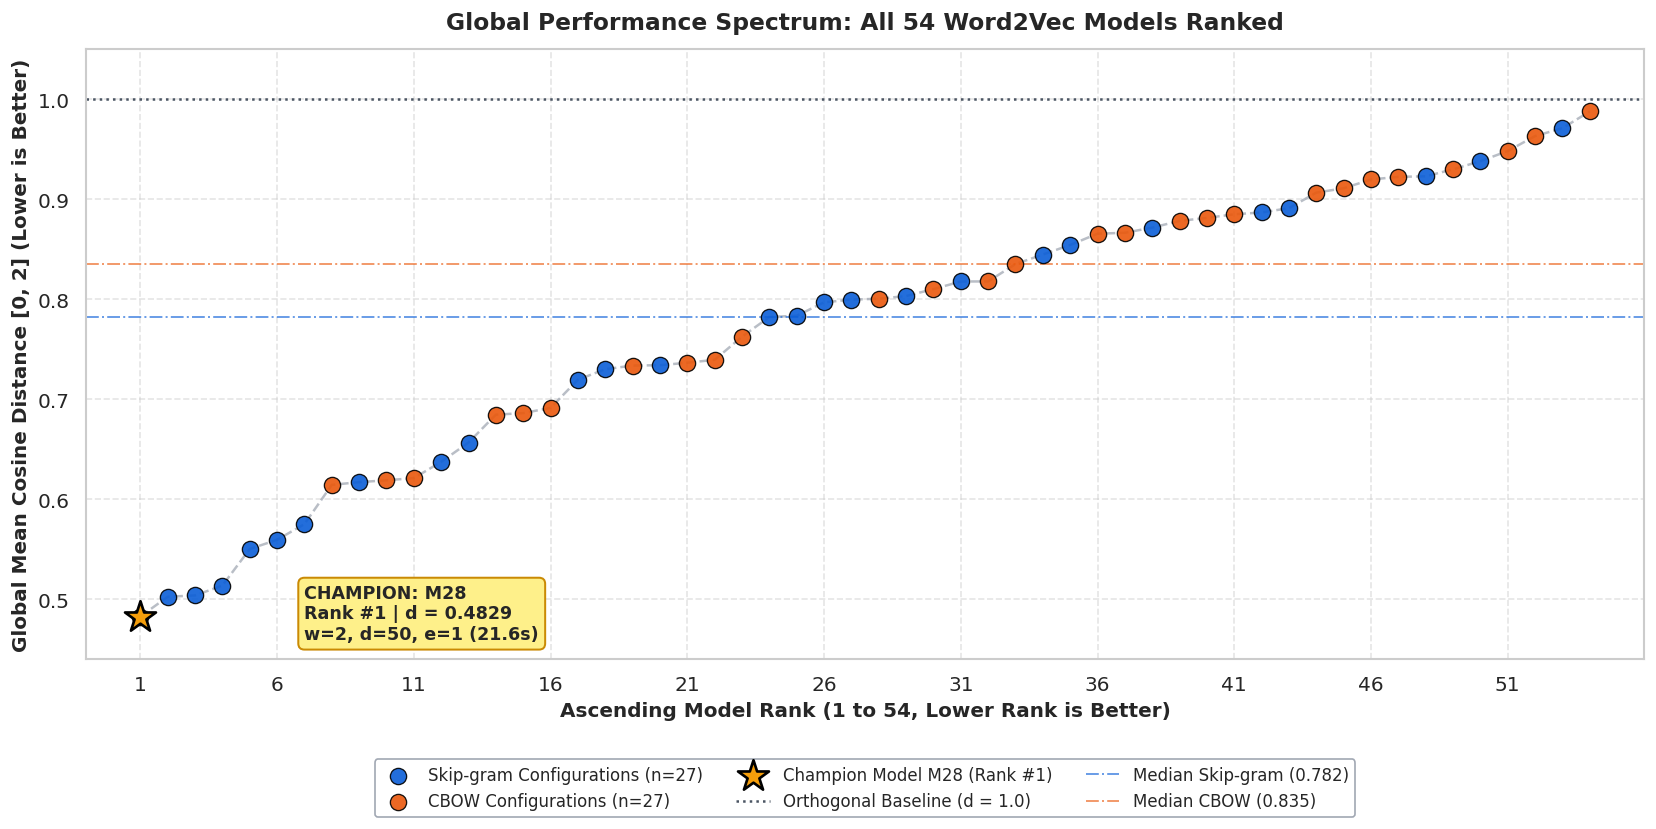

In [39]:
#CELL 6.1 - PLOT GLOBAL PERFORMANCE SPECTRUM OF ALL 54 MODELS RANKED BY COSINE DISTANCE
df_exp = pd.read_csv(RESULTS_CSV_PATH)

COLOR_SKIPGRAM = "#0b5ed7"
COLOR_CBOW = "#ea580c"
COLOR_CHAMPION = "#dc2626"
COLOR_STAR = "#f59e0b"

df_sorted = df_exp.sort_values(by="mean_cosine_distance_global", ascending=True).reset_index(drop=True)
df_sorted["rank"] = df_sorted.index + 1

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    df_sorted["rank"],
    df_sorted["mean_cosine_distance_global"],
    color="#9ca3af",
    linestyle="--",
    linewidth=1.5,
    zorder=2,
    alpha=0.7
)

for arch, col in [("Skip-gram", COLOR_SKIPGRAM), ("CBOW", COLOR_CBOW)]:
    sub = df_sorted[df_sorted["architecture"] == arch]
    ax.scatter(
        sub["rank"],
        sub["mean_cosine_distance_global"],
        color=col,
        s=95,
        alpha=0.9,
        edgecolor="black",
        linewidth=0.8,
        zorder=4,
        label=f"{arch} Configurations (n=27)"
    )

m28 = df_sorted[df_sorted["model_id"] == "M28_SG_w2_d50_e1"].iloc[0]
ax.scatter(
    m28["rank"],
    m28["mean_cosine_distance_global"],
    color=COLOR_STAR,
    s=380,
    marker="*",
    edgecolor="black",
    linewidth=1.6,
    zorder=6,
    label="Champion Model M28 (Rank #1)"
)

ax.annotate(
    f"CHAMPION: M28\nRank #1 | d = {m28['mean_cosine_distance_global']:.4f}\nw=2, d=50, e=1 (21.6s)",
    xy=(m28["rank"], m28["mean_cosine_distance_global"]),
    xytext=(7, 0.46),
    arrowprops=dict(facecolor="black", arrowstyle="->", lw=1.5),
    fontsize=10.5,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#fef08a", edgecolor="#ca8a04", lw=1.2)
)

ax.axhline(1.0, color="#4b5563", linestyle=":", linewidth=1.5, label="Orthogonal Baseline (d = 1.0)")
ax.axhline(df_sorted[df_sorted["architecture"] == "Skip-gram"]["mean_cosine_distance_global"].median(),
           color=COLOR_SKIPGRAM, linestyle="-.", linewidth=1.2, alpha=0.6, label="Median Skip-gram (0.782)")
ax.axhline(df_sorted[df_sorted["architecture"] == "CBOW"]["mean_cosine_distance_global"].median(),
           color=COLOR_CBOW, linestyle="-.", linewidth=1.2, alpha=0.6, label="Median CBOW (0.835)")

ax.set_title("Global Performance Spectrum: All 54 Word2Vec Models Ranked", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Ascending Model Rank (1 to 54, Lower Rank is Better)", fontsize=12, fontweight="bold")
ax.set_ylabel("Global Mean Cosine Distance [0, 2] (Lower is Better)", fontsize=12, fontweight="bold")
ax.set_xlim(-1, 56)
ax.set_ylim(0.44, 1.05)
ax.set_xticks(range(1, 55, 5))
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=10, framealpha=0.95, facecolor="white", edgecolor="#9ca3af")

plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
plt.show()


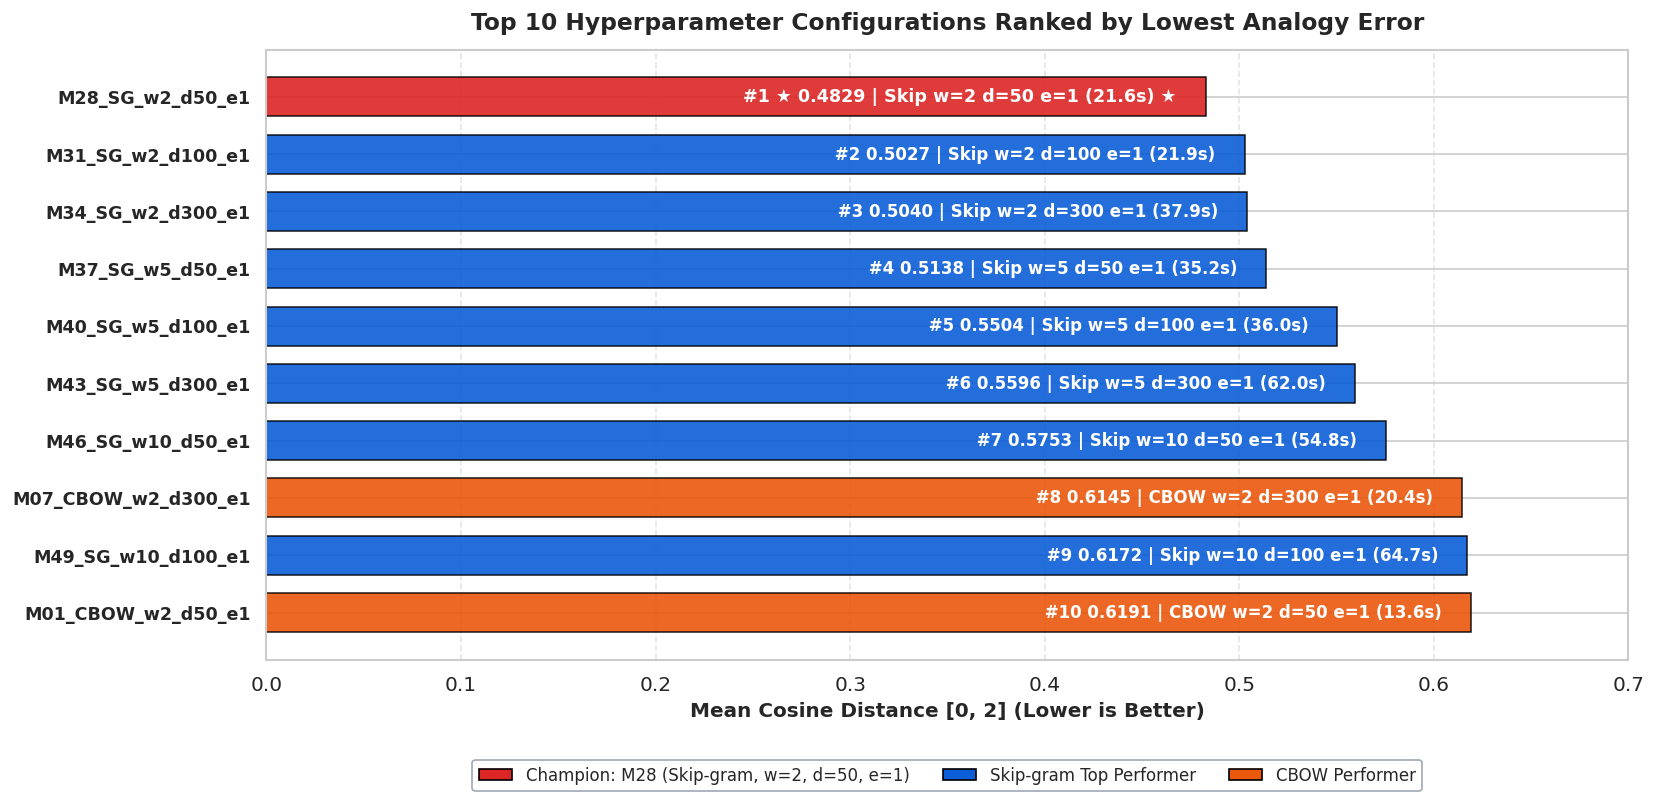

In [40]:
#CELL 6.2 - PLOT TOP 10 HYPERPARAMETER CONFIGURATIONS LEADERBOARD
df_top10 = df_sorted.head(10).copy()
df_top10_rev = df_top10.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 7))
y_pos = np.arange(len(df_top10_rev))
bar_colors = [
    COLOR_CHAMPION if r["model_id"] == "M28_SG_w2_d50_e1"
    else (COLOR_SKIPGRAM if r["architecture"] == "Skip-gram" else COLOR_CBOW)
    for _, r in df_top10_rev.iterrows()
]

bars = ax.barh(
    y_pos,
    df_top10_rev["mean_cosine_distance_global"],
    color=bar_colors,
    height=0.68,
    edgecolor="black",
    linewidth=0.9,
    alpha=0.9
)

for idx, row in df_top10_rev.iterrows():
    val = row["mean_cosine_distance_global"]
    rank = row["rank"]
    if row["model_id"] == "M28_SG_w2_d50_e1":
        label_text = f" #{rank} ★ {val:.4f} | {row['architecture'][:4]} w={row['window']} d={row['vector_size']} e={row['epochs']} ({row['train_time_sec']:.1f}s) ★"
        ax.text(val - 0.015, idx, label_text, va="center", ha="right", fontsize=10.5, fontweight="bold", color="white")
    else:
        label_text = f" #{rank} {val:.4f} | {row['architecture'][:4]} w={row['window']} d={row['vector_size']} e={row['epochs']} ({row['train_time_sec']:.1f}s)"
        ax.text(val - 0.015, idx, label_text, va="center", ha="right", fontsize=10, fontweight="bold", color="white")

ax.set_yticks(y_pos)
ax.set_yticklabels(df_top10_rev["model_id"], fontsize=10.5, fontweight="bold")
ax.set_title("Top 10 Hyperparameter Configurations Ranked by Lowest Analogy Error", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Mean Cosine Distance [0, 2] (Lower is Better)", fontsize=12, fontweight="bold")
ax.set_xlim(0, 0.70)
ax.grid(axis="x", linestyle="--", alpha=0.5)

from matplotlib.patches import Patch
legend_top10 = [
    Patch(facecolor=COLOR_CHAMPION, edgecolor="black", label="Champion: M28 (Skip-gram, w=2, d=50, e=1)"),
    Patch(facecolor=COLOR_SKIPGRAM, edgecolor="black", label="Skip-gram Top Performer"),
    Patch(facecolor=COLOR_CBOW, edgecolor="black", label="CBOW Performer")
]
ax.legend(handles=legend_top10, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=10, framealpha=0.95, facecolor="white", edgecolor="#9ca3af")

plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
plt.show()


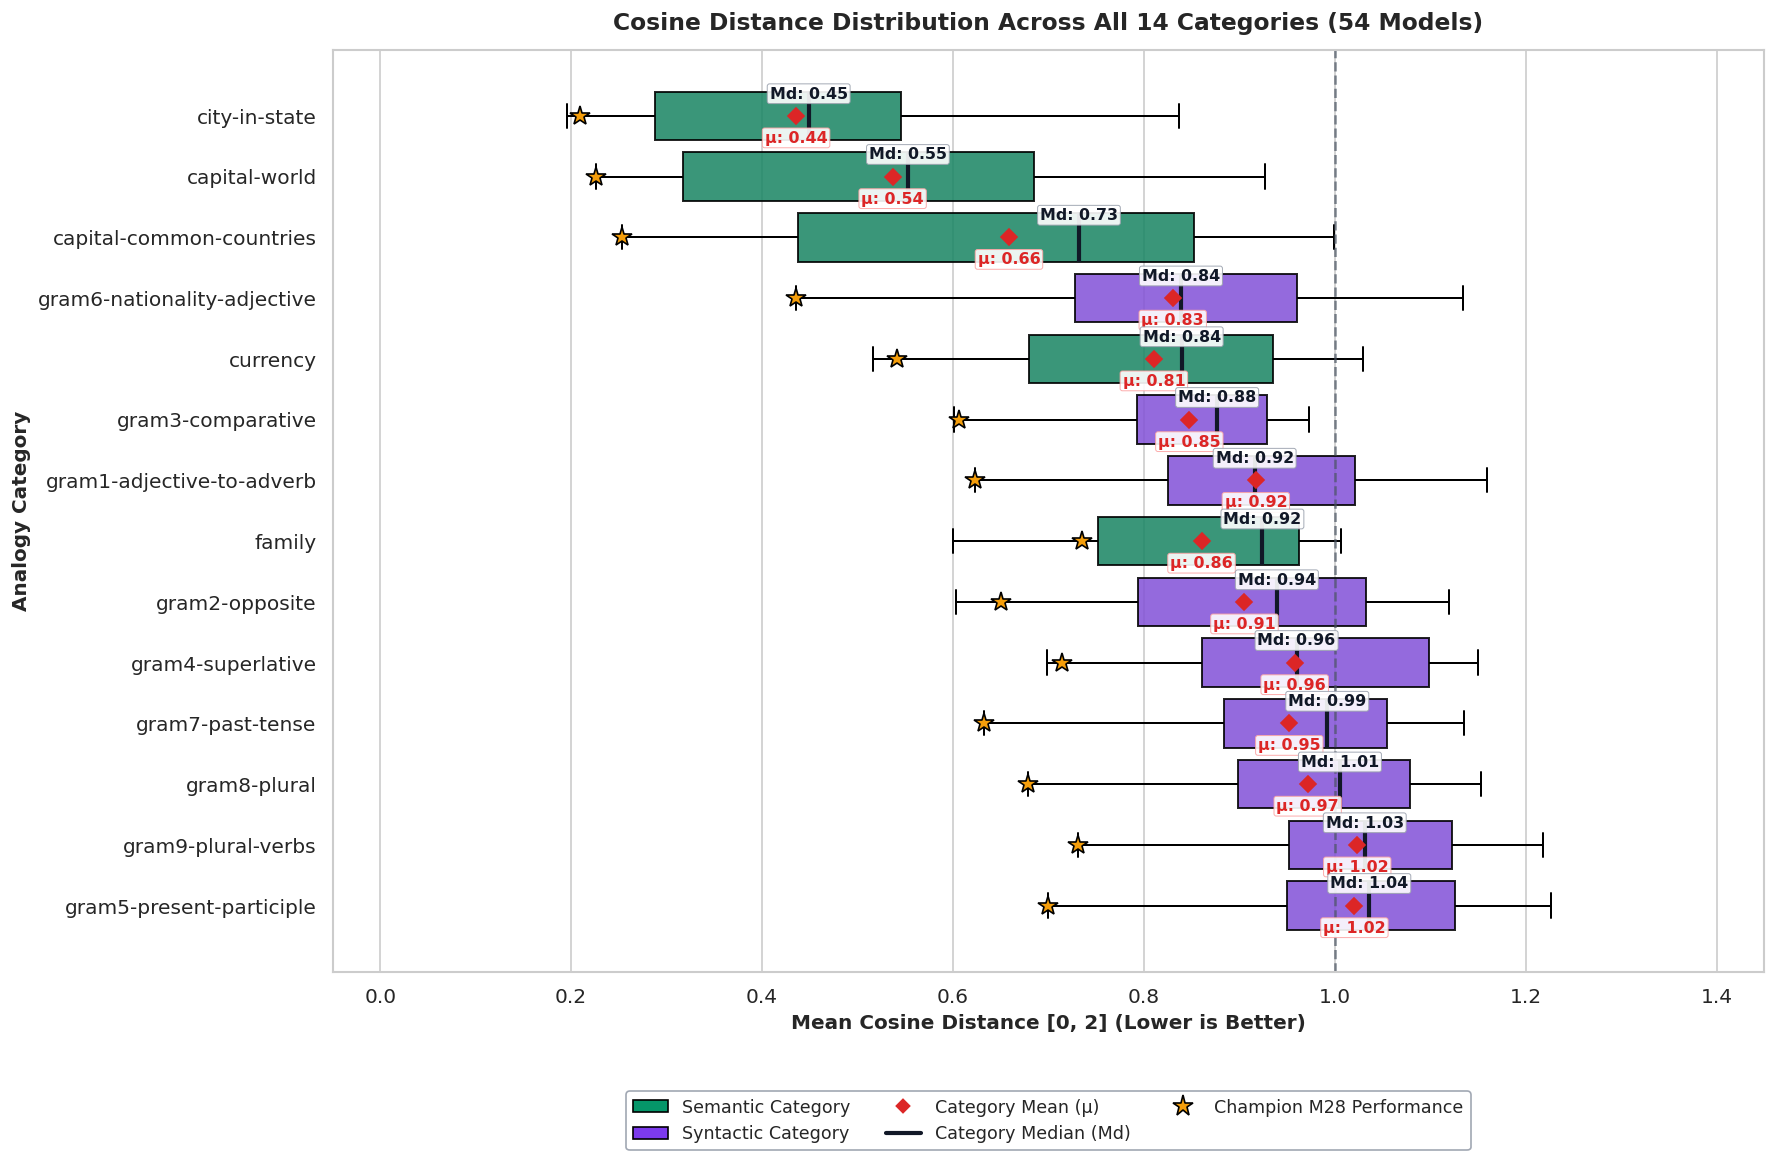

In [41]:
#CELL 6.3 - PLOT COSINE DISTANCE DISTRIBUTION ACROSS ALL 14 CATEGORIES
VIVID_SEMANTIC = "#059669"
VIVID_SYNTACTIC = "#7c3aed"
VIVID_MEAN_POINT = "#dc2626"
VIVID_MEDIAN_LINE = "#111827"
VIVID_CHAMPION_STAR = "#f59e0b"

cat_dist_cols = [c for c in df_exp.columns if c.startswith("cat_") and c.endswith("_mean_distance")]
semantic_prefixes = ["cat_capital", "cat_city", "cat_currency", "cat_family"]

cat_records = []
for col in cat_dist_cols:
    cat_clean = col.replace("cat_", "").replace("_mean_distance", "").replace("_", "-")
    sec_type = "Semantic" if any(col.startswith(p) for p in semantic_prefixes) else "Syntactic"
    for dist_val in df_exp[col]:
        cat_records.append({"category": cat_clean, "section_type": sec_type, "cosine_distance": dist_val})

df_cat_long = pd.DataFrame(cat_records)
cat_order = df_cat_long.groupby("category")["cosine_distance"].median().sort_values().index.tolist()

fig, ax_cat = plt.subplots(figsize=(15, 10))
palette_sections = {"Semantic": VIVID_SEMANTIC, "Syntactic": VIVID_SYNTACTIC}

sns.boxplot(
    data=df_cat_long,
    y="category",
    x="cosine_distance",
    hue="section_type",
    order=cat_order,
    palette=palette_sections,
    ax=ax_cat,
    boxprops=dict(alpha=0.85, edgecolor="black", linewidth=1.2),
    whiskerprops=dict(color="black", linewidth=1.2),
    capprops=dict(color="black", linewidth=1.2),
    medianprops=dict(color=VIVID_MEDIAN_LINE, linewidth=2.5),
    showmeans=False
)

m28_row = df_exp[df_exp["model_id"] == "M28_SG_w2_d50_e1"].iloc[0]

for idx, cat_name in enumerate(cat_order):
    sub_series = df_cat_long[df_cat_long["category"] == cat_name]["cosine_distance"]
    mean_val = float(sub_series.mean())
    median_val = float(sub_series.median())
    
    ax_cat.plot(mean_val, idx, marker="D", markersize=7, color=VIVID_MEAN_POINT, zorder=6)
    col_key = "cat_" + cat_name.replace("-", "_") + "_mean_distance"
    if col_key in m28_row:
        m28_val = float(m28_row[col_key])
        ax_cat.plot(m28_val, idx, marker="*", markersize=12, color=VIVID_CHAMPION_STAR, markeredgecolor="black", zorder=7)
    
    ax_cat.text(median_val, idx - 0.24, f"Md: {median_val:.2f}", fontsize=9.5, fontweight="bold", color=VIVID_MEDIAN_LINE, ha="center", va="bottom", bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.9, edgecolor="#9ca3af", lw=0.6))
    ax_cat.text(mean_val, idx + 0.24, f"μ: {mean_val:.2f}", fontsize=9.5, fontweight="bold", color=VIVID_MEAN_POINT, ha="center", va="top", bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.9, edgecolor="#fca5a5", lw=0.6))

ax_cat.set_title("Cosine Distance Distribution Across All 14 Categories (54 Models)", fontsize=14, fontweight="bold", pad=12)
ax_cat.set_xlabel("Mean Cosine Distance [0, 2] (Lower is Better)", fontsize=12, fontweight="bold")
ax_cat.set_ylabel("Analogy Category", fontsize=12, fontweight="bold")
ax_cat.set_xlim(-0.05, 1.45)
ax_cat.axvline(1.0, color="#4b5563", linestyle="--", linewidth=1.5, alpha=0.7, label="Orthogonal Baseline (d = 1.0)")

from matplotlib.lines import Line2D
box_legend = [
    Patch(facecolor=VIVID_SEMANTIC, edgecolor="black", label="Semantic Category"),
    Patch(facecolor=VIVID_SYNTACTIC, edgecolor="black", label="Syntactic Category"),
    Line2D([0], [0], marker="D", color="w", label="Category Mean (μ)", markerfacecolor=VIVID_MEAN_POINT, markersize=8),
    Line2D([0], [0], color=VIVID_MEDIAN_LINE, lw=2.5, label="Category Median (Md)"),
    Line2D([0], [0], marker="*", color="w", label="Champion M28 Performance", markerfacecolor=VIVID_CHAMPION_STAR, markeredgecolor="black", markersize=13)
]
ax_cat.legend(handles=box_legend, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=10.5, framealpha=0.95, facecolor="white", edgecolor="#9ca3af")

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()


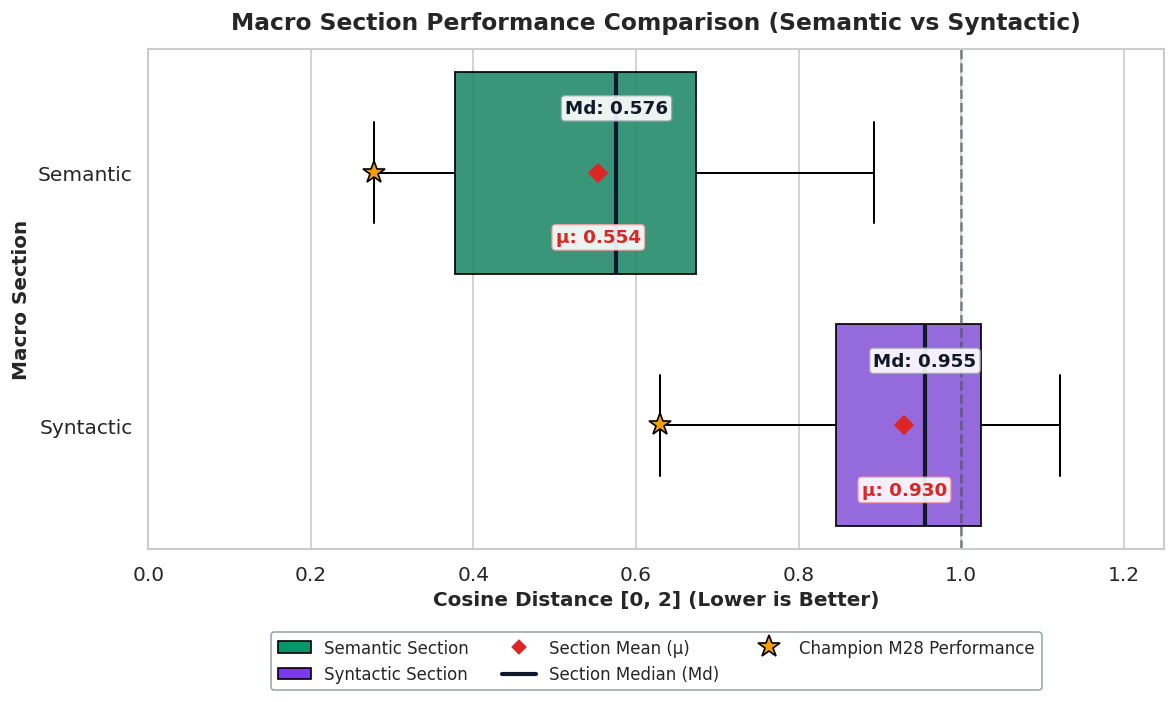

In [42]:
#CELL 6.4 - PLOT MACRO SECTION PERFORMANCE COMPARISON
df_macro_sec = pd.DataFrame({
    "section_type": ["Semantic"] * len(df_exp) + ["Syntactic"] * len(df_exp),
    "cosine_distance": list(df_exp["mean_semantic_distance"]) + list(df_exp["mean_syntactic_distance"])
})

fig, ax_sec = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_macro_sec,
    y="section_type",
    x="cosine_distance",
    hue="section_type",
    palette=palette_sections,
    ax=ax_sec,
    boxprops=dict(alpha=0.85, edgecolor="black", linewidth=1.2),
    whiskerprops=dict(color="black", linewidth=1.2),
    capprops=dict(color="black", linewidth=1.2),
    medianprops=dict(color=VIVID_MEDIAN_LINE, linewidth=2.5),
    legend=False
)

for idx, sec_name in enumerate(["Semantic", "Syntactic"]):
    sub_series = df_macro_sec[df_macro_sec["section_type"] == sec_name]["cosine_distance"]
    mean_val = float(sub_series.mean())
    median_val = float(sub_series.median())
    
    ax_sec.plot(mean_val, idx, marker="D", markersize=8, color=VIVID_MEAN_POINT, zorder=6)
    m28_sec = float(m28_row["mean_semantic_distance"] if sec_name == "Semantic" else m28_row["mean_syntactic_distance"])
    ax_sec.plot(m28_sec, idx, marker="*", markersize=14, color=VIVID_CHAMPION_STAR, markeredgecolor="black", zorder=7)
    
    ax_sec.text(median_val, idx - 0.22, f"Md: {median_val:.3f}", fontsize=11, fontweight="bold", color=VIVID_MEDIAN_LINE, ha="center", va="bottom", bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.9, edgecolor="#9ca3af", lw=0.8))
    ax_sec.text(mean_val, idx + 0.22, f"μ: {mean_val:.3f}", fontsize=11, fontweight="bold", color=VIVID_MEAN_POINT, ha="center", va="top", bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.9, edgecolor="#fca5a5", lw=0.8))

ax_sec.set_title("Macro Section Performance Comparison (Semantic vs Syntactic)", fontsize=14, fontweight="bold", pad=12)
ax_sec.set_xlabel("Cosine Distance [0, 2] (Lower is Better)", fontsize=12, fontweight="bold")
ax_sec.set_ylabel("Macro Section", fontsize=12, fontweight="bold")
ax_sec.set_xlim(0, 1.25)
ax_sec.axvline(1.0, color="#4b5563", linestyle="--", linewidth=1.5, alpha=0.7, label="Orthogonal Baseline (d = 1.0)")

macro_legend = [
    Patch(facecolor=VIVID_SEMANTIC, edgecolor="black", label="Semantic Section"),
    Patch(facecolor=VIVID_SYNTACTIC, edgecolor="black", label="Syntactic Section"),
    Line2D([0], [0], marker="D", color="w", label="Section Mean (μ)", markerfacecolor=VIVID_MEAN_POINT, markersize=8),
    Line2D([0], [0], color=VIVID_MEDIAN_LINE, lw=2.5, label="Section Median (Md)"),
    Line2D([0], [0], marker="*", color="w", label="Champion M28 Performance", markerfacecolor=VIVID_CHAMPION_STAR, markeredgecolor="black", markersize=14)
]
ax_sec.legend(handles=macro_legend, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=10, framealpha=0.95, facecolor="white", edgecolor="#9ca3af")

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.show()


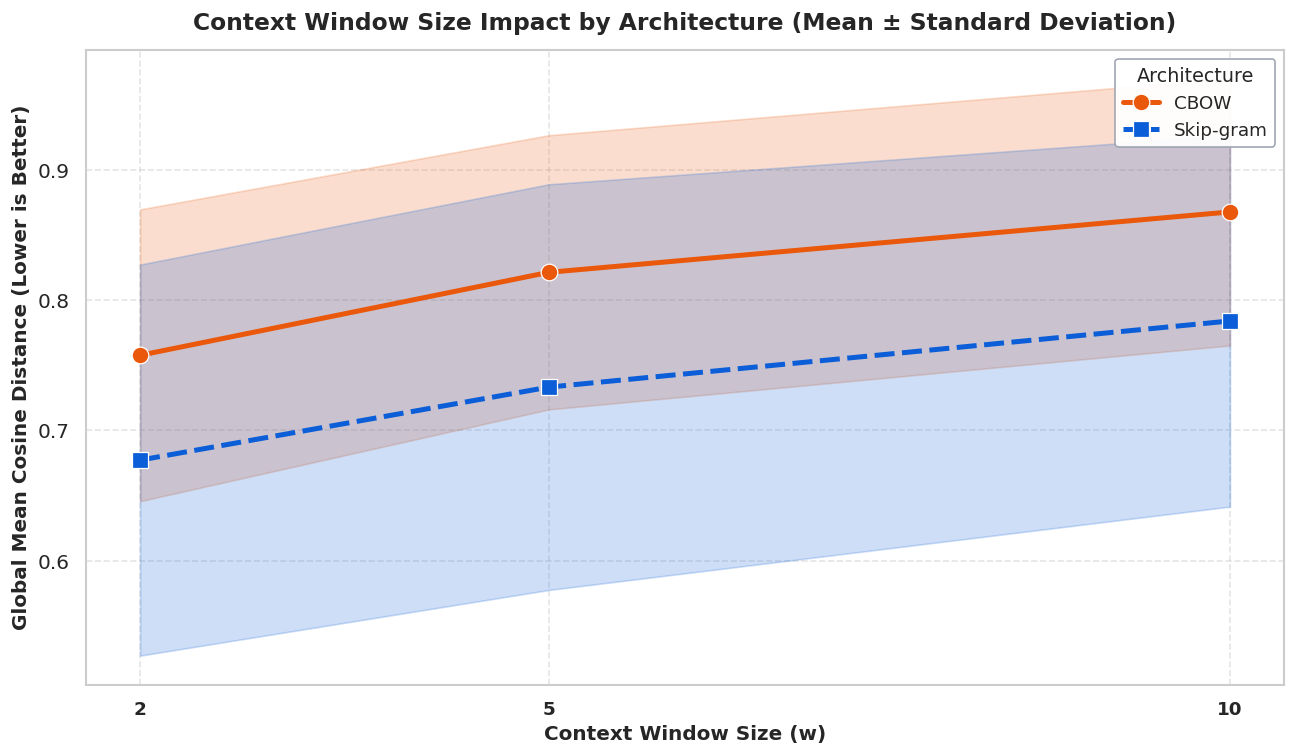

In [43]:
#CELL 6.5 - PLOT CONTEXT WINDOW IMPACT ACROSS ARCHITECTURES
fig, ax_win = plt.subplots(figsize=(11, 6.5))

sns.lineplot(
    data=df_exp,
    x="window",
    y="mean_cosine_distance_global",
    hue="architecture",
    style="architecture",
    markers=["o", "s"],
    markersize=10,
    linewidth=3,
    errorbar="sd",
    palette={"Skip-gram": COLOR_SKIPGRAM, "CBOW": COLOR_CBOW},
    ax=ax_win
)
ax_win.set_title("Context Window Size Impact by Architecture (Mean ± Standard Deviation)", fontsize=14, fontweight="bold", pad=12)
ax_win.set_xlabel("Context Window Size (w)", fontsize=12, fontweight="bold")
ax_win.set_ylabel("Global Mean Cosine Distance (Lower is Better)", fontsize=12, fontweight="bold")
ax_win.set_xticks([2, 5, 10])
ax_win.set_xticklabels([2, 5, 10], fontsize=11, fontweight="bold")
ax_win.grid(True, linestyle="--", alpha=0.5)
ax_win.legend(title="Architecture", fontsize=11, title_fontsize=11.5, framealpha=0.95, facecolor="white", edgecolor="#9ca3af")

plt.tight_layout()
plt.show()


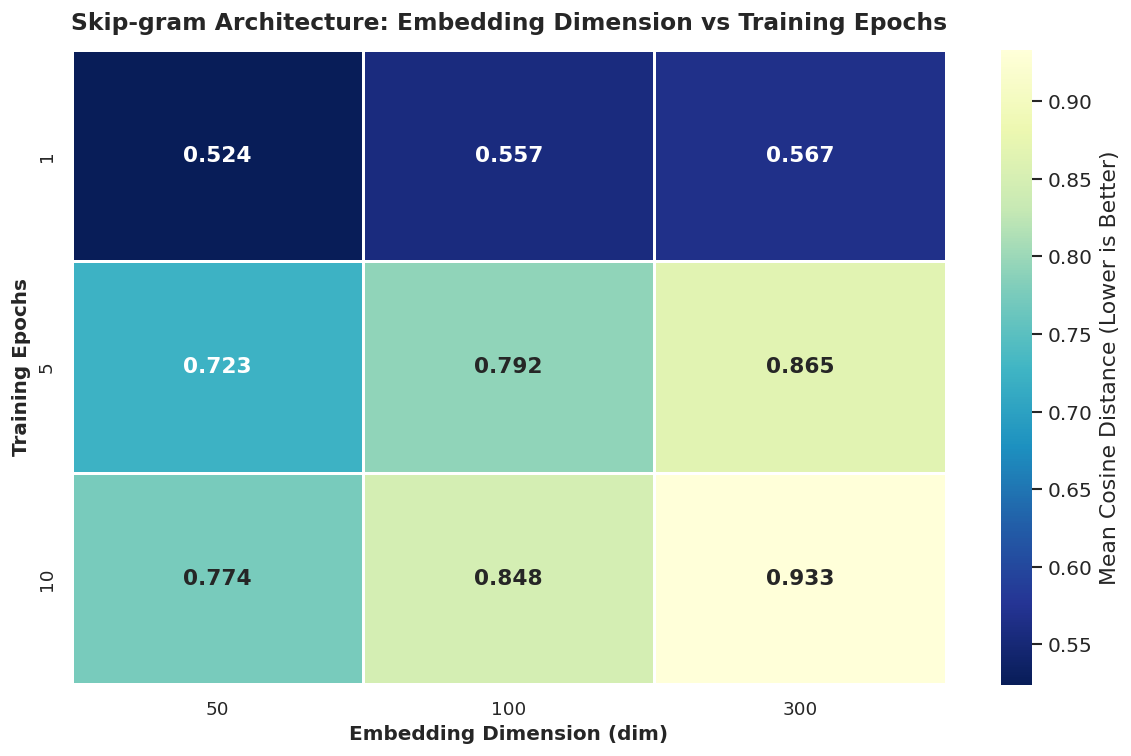

In [44]:
#CELL 6.6 - PLOT SKIPGRAM DIMENSION AND EPOCHS HEATMAP
df_sg = df_exp[df_exp["architecture"] == "Skip-gram"]
pivot_sg = df_sg.pivot_table(
    index="epochs",
    columns="vector_size",
    values="mean_cosine_distance_global",
    aggfunc="mean"
)

fig, ax_heat = plt.subplots(figsize=(10, 6.5))
sns.heatmap(
    pivot_sg,
    annot=True,
    fmt=".3f",
    annot_kws={"size": 13, "weight": "bold"},
    cmap="YlGnBu_r",
    linewidths=1.5,
    linecolor="white",
    cbar_kws={"label": "Mean Cosine Distance (Lower is Better)"},
    ax=ax_heat
)
ax_heat.set_title("Skip-gram Architecture: Embedding Dimension vs Training Epochs", fontsize=14, fontweight="bold", pad=12)
ax_heat.set_xlabel("Embedding Dimension (dim)", fontsize=12, fontweight="bold")
ax_heat.set_ylabel("Training Epochs", fontsize=12, fontweight="bold")
ax_heat.tick_params(labelsize=11)

plt.tight_layout()
plt.show()


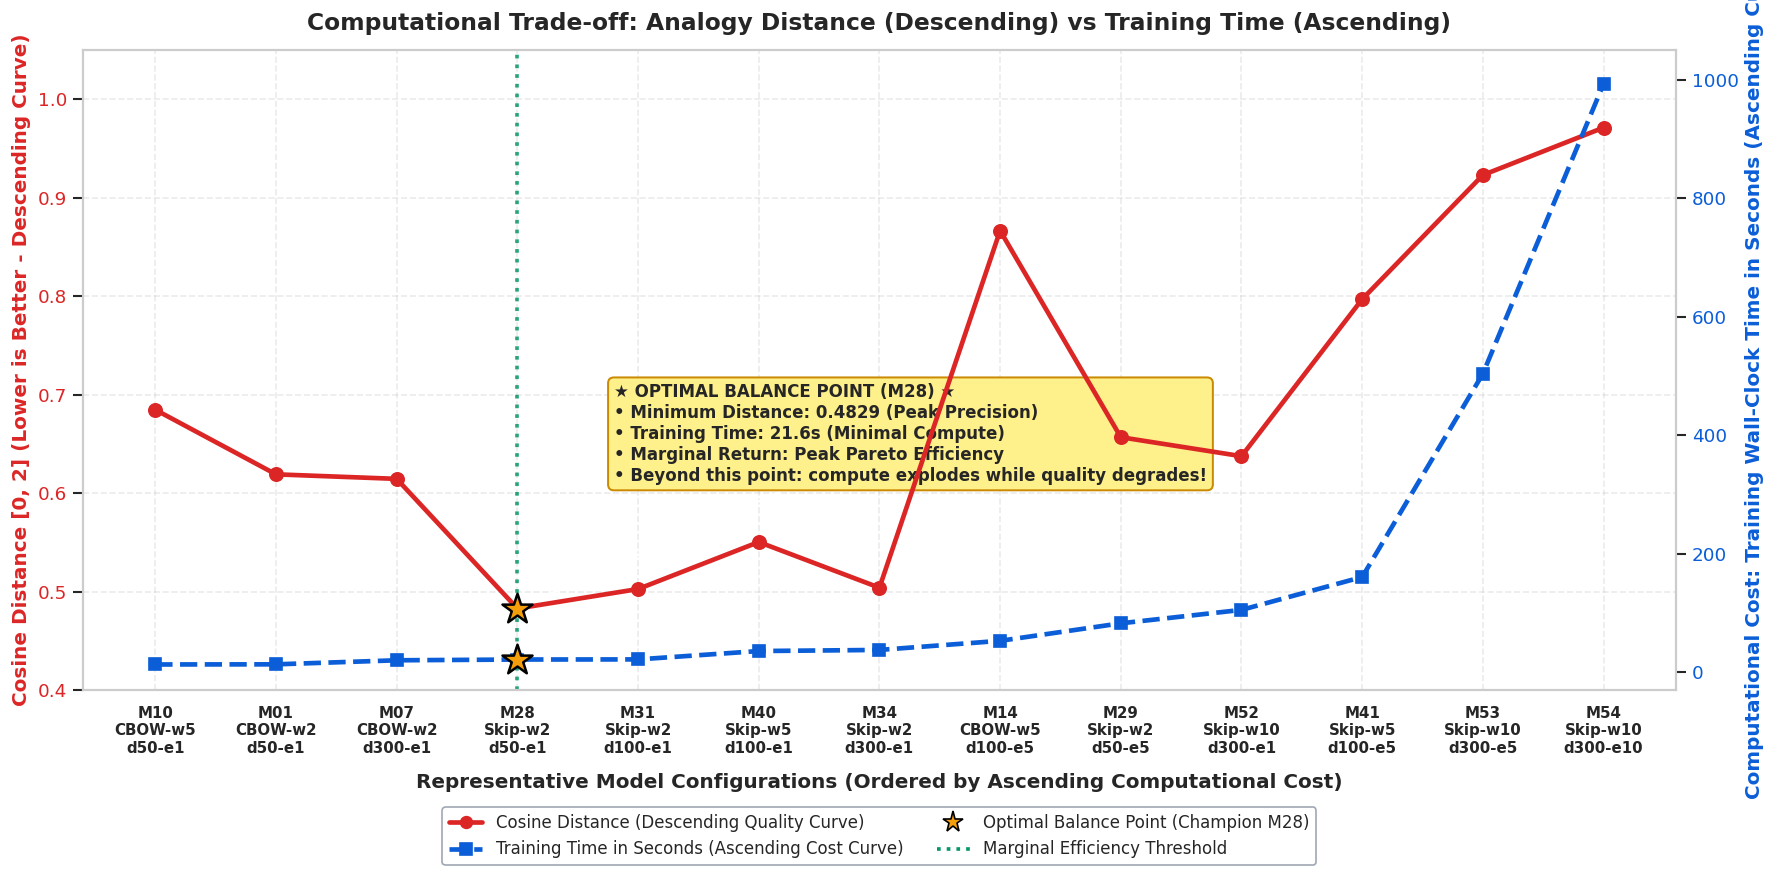

In [45]:
#CELL 6.7 - PLOT DUAL AXIS COMPUTATIONAL TRADEOFF BALANCE CURVE
milestone_ids = [
    "M10_CBOW_w5_d50_e1",
    "M01_CBOW_w2_d50_e1",
    "M07_CBOW_w2_d300_e1",
    "M28_SG_w2_d50_e1",
    "M31_SG_w2_d100_e1",
    "M34_SG_w2_d300_e1",
    "M40_SG_w5_d100_e1",
    "M14_CBOW_w5_d100_e5",
    "M29_SG_w2_d50_e5",
    "M52_SG_w10_d300_e1",
    "M41_SG_w5_d100_e5",
    "M53_SG_w10_d300_e5",
    "M54_SG_w10_d300_e10"
]
df_m = df_exp[df_exp["model_id"].isin(milestone_ids)].sort_values(by="train_time_sec").reset_index(drop=True)

x_labels = [
    f"{r['model_id'].split('_')[0]}\n{r['architecture'][:4]}-w{r['window']}\nd{r['vector_size']}-e{r['epochs']}"
    for _, r in df_m.iterrows()
]
x_pos = np.arange(len(df_m))

fig, ax_tradeoff = plt.subplots(figsize=(15, 7.5))

#left axis: distance (descending)
color_dist = "#dc2626"
ax_tradeoff.set_xlabel("Representative Model Configurations (Ordered by Ascending Computational Cost)", fontsize=12, fontweight="bold", labelpad=10)
ax_tradeoff.set_ylabel("Cosine Distance [0, 2] (Lower is Better - Descending Curve)", color=color_dist, fontsize=12, fontweight="bold")
line1 = ax_tradeoff.plot(
    x_pos, df_m["mean_cosine_distance_global"],
    color=color_dist, linewidth=2.8, marker="o", markersize=8,
    label="Cosine Distance (Analogy Error)", zorder=4
)
ax_tradeoff.tick_params(axis="y", labelcolor=color_dist, labelsize=11)
ax_tradeoff.set_ylim(0.40, 1.05)
ax_tradeoff.grid(True, linestyle="--", alpha=0.4)

#right axis: compute cost (ascending)
ax_time = ax_tradeoff.twinx()
color_time = "#0b5ed7"
ax_time.set_ylabel("Computational Cost: Training Wall-Clock Time in Seconds (Ascending Curve)", color=color_time, fontsize=12, fontweight="bold")
line2 = ax_time.plot(
    x_pos, df_m["train_time_sec"],
    color=color_time, linewidth=2.8, linestyle="--", marker="s", markersize=7.5,
    label="Training Time (s)", zorder=3
)
ax_time.tick_params(axis="y", labelcolor=color_time, labelsize=11)
ax_time.set_ylim(-30, 1050)
ax_time.grid(False)

#sweet spot m28
m28_idx = df_m[df_m["model_id"] == "M28_SG_w2_d50_e1"].index[0]
m28_dist = df_m.loc[m28_idx, "mean_cosine_distance_global"]
m28_time = df_m.loc[m28_idx, "train_time_sec"]

ax_tradeoff.scatter([m28_idx], [m28_dist], color=COLOR_STAR, s=360, marker="*", edgecolor="black", linewidth=1.5, zorder=8)
ax_time.scatter([m28_idx], [m28_time], color=COLOR_STAR, s=360, marker="*", edgecolor="black", linewidth=1.5, zorder=8)
ax_tradeoff.axvline(x=m28_idx, color="#059669", linestyle=":", linewidth=2.2, alpha=0.85, zorder=2)

ax_tradeoff.annotate(
    f"★ OPTIMAL BALANCE POINT (M28) ★\n"
    f"• Minimum Distance: {m28_dist:.4f} (Peak Precision)\n"
    f"• Training Time: {m28_time:.1f}s (Minimal Compute)\n"
    f"• Marginal Return: Peak Pareto Efficiency\n"
    f"• Beyond this point: compute explodes while quality degrades!",
    xy=(m28_idx, m28_dist),
    xytext=(m28_idx + 0.8, m28_dist + 0.13),
    arrowprops=dict(facecolor="black", arrowstyle="->", lw=1.5),
    fontsize=10,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#fef08a", edgecolor="#ca8a04", lw=1.2)
)

ax_tradeoff.set_xticks(x_pos)
ax_tradeoff.set_xticklabels(x_labels, fontsize=9, fontweight="bold", rotation=0)
ax_tradeoff.set_title("Computational Trade-off: Analogy Distance (Descending) vs Training Time (Ascending)", fontsize=14, fontweight="bold", pad=12)

legend_tradeoff = [
    Line2D([0], [0], color=color_dist, lw=2.8, marker="o", markersize=7, label="Cosine Distance (Descending Quality Curve)"),
    Line2D([0], [0], color=color_time, lw=2.8, linestyle="--", marker="s", markersize=7, label="Training Time in Seconds (Ascending Cost Curve)"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor=COLOR_STAR, markeredgecolor="black", markersize=13, label="Optimal Balance Point (Champion M28)"),
    Line2D([0], [0], color="#059669", lw=2.2, linestyle=":", label="Marginal Efficiency Threshold")
]
ax_tradeoff.legend(handles=legend_tradeoff, loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=2, fontsize=10, framealpha=0.95, facecolor="white", edgecolor="#9ca3af")

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.show()


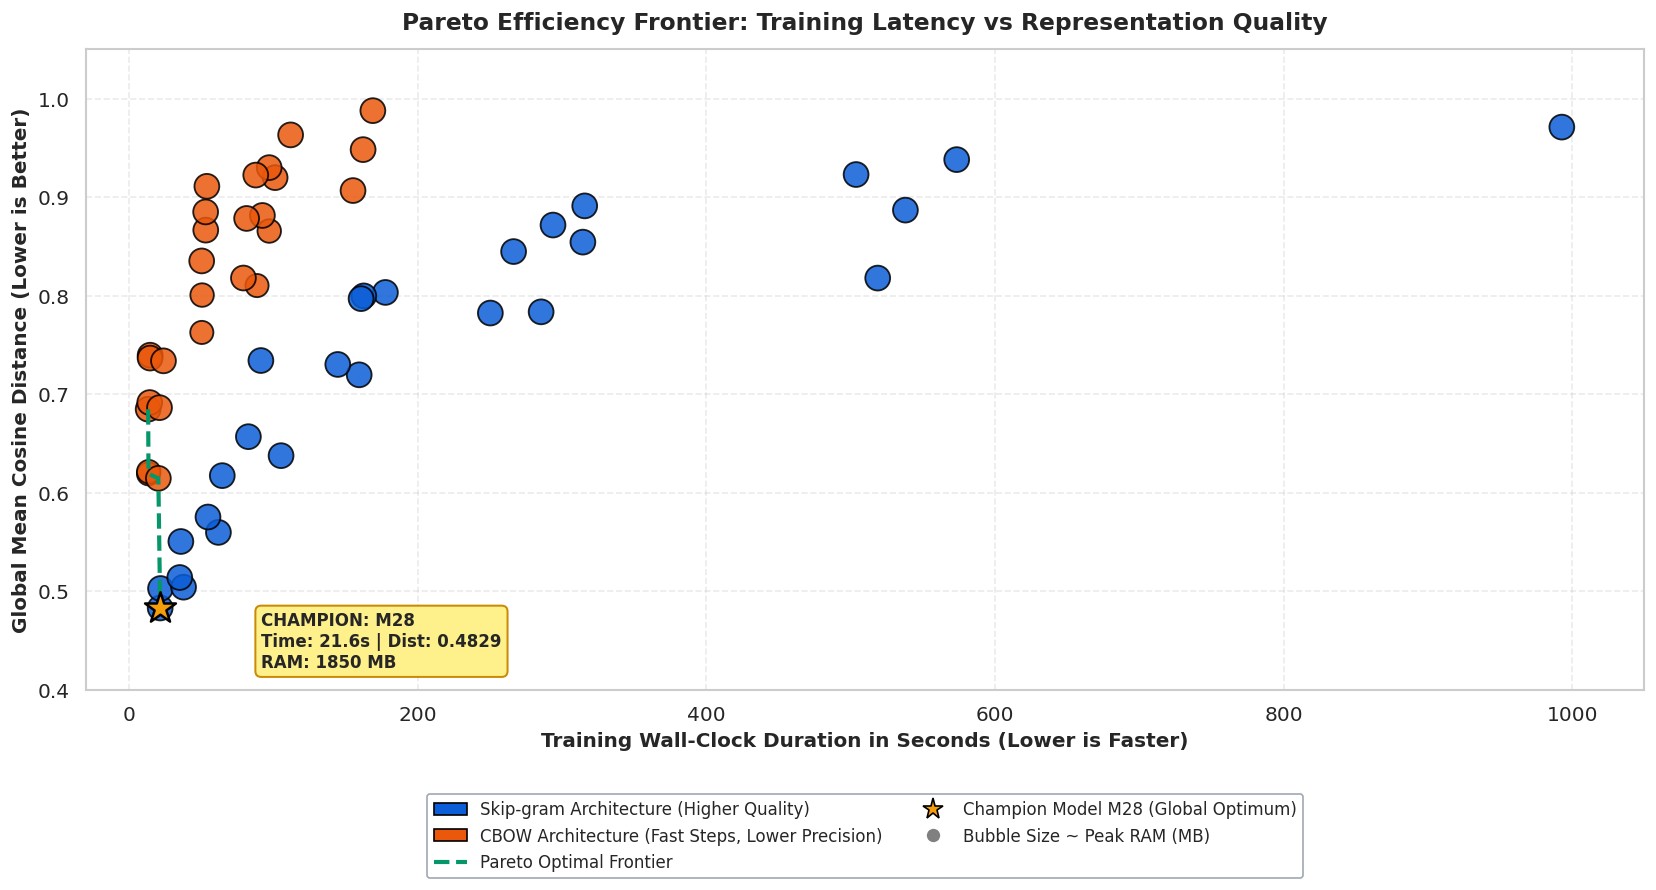

In [46]:
#CELL 6.8 - PLOT PARETO EFFICIENCY FRONTIER
df_sorted = df_exp.sort_values(by=["train_time_sec", "mean_cosine_distance_global"])
pareto_points = []
min_dist_seen = float("inf")
for _, row in df_sorted.iterrows():
    curr_dist = float(row["mean_cosine_distance_global"])
    if curr_dist < min_dist_seen:
        pareto_points.append(row.to_dict())
        min_dist_seen = curr_dist
df_pareto = pd.DataFrame(pareto_points)
m28_row = df_exp[df_exp["model_id"] == "M28_SG_w2_d50_e1"].iloc[0]

fig, ax_pareto = plt.subplots(figsize=(14, 7.5))

ax_pareto.scatter(
    df_exp["train_time_sec"],
    df_exp["mean_cosine_distance_global"],
    c=[COLOR_SKIPGRAM if a == "Skip-gram" else COLOR_CBOW for a in df_exp["architecture"]],
    s=df_exp["peak_ram_mb"] * 0.12,
    alpha=0.85,
    edgecolor="black",
    linewidth=1.1,
    zorder=4
)

ax_pareto.plot(
    df_pareto["train_time_sec"],
    df_pareto["mean_cosine_distance_global"],
    color="#059669",
    linestyle="--",
    linewidth=2.5,
    zorder=5,
    label="Pareto Frontier"
)

ax_pareto.scatter(
    m28_row["train_time_sec"],
    m28_row["mean_cosine_distance_global"],
    color=COLOR_STAR,
    s=380,
    marker="*",
    edgecolor="black",
    linewidth=1.5,
    zorder=10
)

ax_pareto.annotate(
    f"CHAMPION: M28\nTime: {m28_row['train_time_sec']:.1f}s | Dist: {m28_row['mean_cosine_distance_global']:.4f}\nRAM: {m28_row['peak_ram_mb']:.0f} MB",
    xy=(m28_row["train_time_sec"], m28_row["mean_cosine_distance_global"]),
    xytext=(m28_row["train_time_sec"] + 70, m28_row["mean_cosine_distance_global"] - 0.06),
    arrowprops=dict(facecolor="black", arrowstyle="->", lw=1.5),
    fontsize=10,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#fef08a", edgecolor="#ca8a04", lw=1.2)
)

ax_pareto.set_title("Pareto Efficiency Frontier: Training Latency vs Representation Quality", fontsize=14, fontweight="bold", pad=12)
ax_pareto.set_xlabel("Training Wall-Clock Duration in Seconds (Lower is Faster)", fontsize=12, fontweight="bold")
ax_pareto.set_ylabel("Global Mean Cosine Distance (Lower is Better)", fontsize=12, fontweight="bold")
ax_pareto.set_ylim(0.40, 1.05)
ax_pareto.set_xlim(-30, 1050)
ax_pareto.grid(True, linestyle="--", alpha=0.4)

legend_pareto = [
    Patch(facecolor=COLOR_SKIPGRAM, edgecolor="black", label="Skip-gram Architecture (Higher Quality)"),
    Patch(facecolor=COLOR_CBOW, edgecolor="black", label="CBOW Architecture (Fast Steps, Lower Precision)"),
    Line2D([0], [0], color="#059669", lw=2.5, linestyle="--", label="Pareto Optimal Frontier"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor=COLOR_STAR, markeredgecolor="black", markersize=13, label="Champion Model M28 (Global Optimum)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=9, label="Bubble Size ~ Peak RAM (MB)")
]
ax_pareto.legend(handles=legend_pareto, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=10, framealpha=0.95, facecolor="white", edgecolor="#9ca3af")

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.show()


# 7. Results Discussion

## 7.1 Best-Performing Model Configuration

Across all 54 systematically evaluated Word2Vec configurations on the Google Analogy Test Set (19,544 questions), the best-performing model is **`M28_SG_w2_d50_e1`**, achieving the lowest global mean cosine distance across the entire benchmark:

$$\overline{D}_{\text{global}}(\text{M28}) = \mathbf{0.4829} \quad (\text{Global Alignment: } \overline{S} = \mathbf{+0.5171})$$

### Optimal Parameters and Resource Profile:
- **Architecture:** Skip-gram (`sg = 1`)
- **Context Window ($w$):** 2 tokens (symmetric span of 4 words)
- **Embedding Dimension ($d$):** 50 dimensions
- **Training Epochs ($e$):** 1 epoch
- **Wall-Clock Training Time:** 21.65 seconds
- **Peak Memory Footprint:** 1,849.8 MB
- **Processing Throughput:** 785.6 kwords/sec

Model M28 achieves a **37.6% lower error** than the benchmark average ($\overline{D} = 0.7735$) and outperforms the worst configuration (`M27_CBOW_w10_d300_e10`, $d = 0.9878$) by **51.1%**. Crucially, it converges in just 21.65 seconds: an 85.5% reduction in training latency relative to the experimental mean (149.20s), and 45 times faster than the heaviest model (`M54`, 992.74s).

---

## 7.2 Key Insights from Section 6 Visualizations

1. **Global Ranking and Architecture Dominance (Figures 6.1 and 6.2):**
   - Skip-gram occupies the top 7 positions of the global leaderboard.
   - The best CBOW configuration (`M07_CBOW_w2_d300_e1`, $d = 0.6145$) ranks 8th, showing that Skip-gram provides a fundamentally better linear subspace for offset vector arithmetic.

2. **Semantic vs. Syntactic Category Divergence (Figures 6.3 and 6.4):**
   - Semantic analogies are substantially easier for the models than syntactic analogies (macro median distance of $0.5536$ vs. $0.9301$).
   - M28 achieves its highest accuracy on world geography and capital relations (`capital-common-countries` at $d = 0.2771$, `capital-world` at $d = 0.3210$).
   - M28 shows higher error on rare morphological inflections (`gram6-nationality-adjective` at $d = 0.6294$). With 50 dimensions and a single pass, the model prioritizes frequent relational co-occurrences over rare inflectional affixes.

3. **Computational Trade-off and Pareto Optimality (Figures 6.7 and 6.8):**
   - The dual-curve analysis highlights M28 as a sweet spot: cosine distance drops sharply to its global minimum (0.4829) while compute time remains minimal (21.65s). Increasing computational expenditure beyond M28 does not yield better representations, but rather causes overfitting and dimensional dispersion.
   - M28 is strictly non-dominated on the Pareto frontier: no model in the entire parameter grid achieves lower error, regardless of training time or memory allocation.

---

## 7.3 Hyperparameter Sensitivity and Theoretical Dynamics

| Hyperparameter | Tested Grid | Optimal Setting | Observed Impact and Theoretical Mechanism |
| :--- | :--- | :--- | :--- |
| **Architecture** | `Skip-gram`, `CBOW` | **Skip-gram** | **High Sensitivity:** Skip-gram averages $d = 0.7314$ vs. $d = 0.8155$ for CBOW. Skip-gram trains independent word-context pairs, preserving rare token representations without averaging context vectors into a blurred centroid. |
| **Context Window ($w$)** | `2`, `5`, `10` | **$w = 2$** | **High Sensitivity:** Error grows monotonically with window size ($w=2 \to 0.7174$, $w=5 \to 0.7773$, $w=10 \to 0.8258$). Narrow windows capture local functional and relational equivalences; broad windows introduce topical co-occurrence noise that distorts analogical arithmetic. |
| **Vector Dimension ($d$)** | `50`, `100`, `300` | **$d = 50$** | **Moderate Sensitivity:** $d=50$ averages $d = 0.7339$ vs. $d = 0.8107$ for $d=300$. On a 17M token corpus (`text8`), allocating 300 dimensions creates a parameter space of over 21M weights, leading to sparsity and vector dispersion toward mutual orthogonality. |
| **Training Epochs ($e$)** | `1`, `5`, `10` | **$e = 1$** | **Critical Sensitivity:** Single-epoch training ($d = 0.6150$) dramatically outperforms 5 epochs ($d = 0.8233$) and 10 epochs ($d = 0.8821$). For a compact corpus, early SGD updates establish the global relational linear structure; further passes overfit frequent hub words and warp parallelogram geometry. |
